# Threshold-Dependent Dominance in Tail Risk Approximation
## Replication notebook

**Author.** Terence D. Agbeyegbe, Department of Economics, Hunter College and the Graduate Center, City University of New York.

This notebook reproduces all numerical results in the paper, including the robustness extensions to four alternative return distributions and the empirical application to S&P 500 and sector-ETF returns.

**To run.** *Runtime → Run all*. Full mode takes approximately 25–30 minutes on a standard Colab CPU runtime. Set `FAST_MODE = True` in the setup cell for a quick smoke test (~ 2 minutes).

**Reproducibility.** Random seed `456`. Library versions pinned. Empirical data are read from `sp500_returns.csv` which ships with the package.

## 0. Setup

In [1]:
import sys, subprocess
def _pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *args])
# Uncomment to pin versions exactly:
# _pip("numpy==1.26.4", "scipy==1.13.0", "pandas==2.2.2", "matplotlib==3.8.4")

import numpy as np
import scipy
import pandas as pd
import matplotlib
print(f"numpy:      {np.__version__}")
print(f"scipy:      {scipy.__version__}")
print(f"pandas:     {pd.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

numpy:      2.0.2
scipy:      1.16.3
pandas:     2.2.2
matplotlib: 3.10.0


In [2]:
import os, time, warnings
from datetime import datetime
from scipy import stats
from scipy.special import gammaln
from scipy.optimize import brentq, newton
from scipy.integrate import quad
warnings.filterwarnings("ignore")

# ---------------- Configuration ----------------
FAST_MODE = False
SEED      = 456
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PI_GRID  = np.linspace(0.005, 0.030, 18)
DEL_GRID = np.linspace(3.0,   12.0, 36)
THRESHOLDS_TAIL = [-2.0, -2.33, -3.0, -3.5]
THRESHOLD_FOCUS = -3.0
ALPHA_ES        = 0.01
MC_REPS    = 100
MC_SAMPLES = 100_000

HANSEN_ETA  = [5, 6, 8, 10, 15, 30]
HANSEN_LAM  = [-0.5, -0.3, -0.1, 0.0, 0.1, 0.3, 0.5]
GED_NU      = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0, 5.0]
JUMP_PI_UP    = [0.005, 0.010, 0.020]
JUMP_PI_DOWN  = [0.005, 0.010, 0.020]
JUMP_DELTA_UP = [3.0, 5.0, 7.0]
JUMP_DELTA_DN = [3.0, 5.0, 7.0]
GH_LAM = [-1.0, -0.5, 0.0, 0.5, 1.0]
GH_A   = [1.5, 2.0, 3.0]
GH_B   = [-0.5, -0.2, 0.0, 0.2, 0.5]

EMPIRICAL_FILE = "sample_data/sp500_returns.csv"
ROLLING_WINDOW = 250

if FAST_MODE:
    PI_GRID  = np.linspace(0.005, 0.030,  6)
    DEL_GRID = np.linspace(3.0,   12.0,  12)
    HANSEN_ETA = [5, 10, 30]; HANSEN_LAM = [-0.3, 0.0, 0.3]
    GED_NU = [0.8, 1.5, 3.0]
    JUMP_PI_UP=[0.010]; JUMP_PI_DOWN=[0.010]
    JUMP_DELTA_UP=[3.0, 5.0]; JUMP_DELTA_DN=[3.0, 5.0]
    GH_LAM=[-0.5, 0.0, 0.5]; GH_A=[2.0]; GH_B=[-0.2, 0.0, 0.2]
    MC_REPS = 0
    ROLLING_WINDOW = 100
    print("*** FAST MODE ENABLED ***")
else:
    print("Full mode")

np.random.seed(SEED)
np.set_printoptions(precision=6, suppress=True)
print(f"Seed: {SEED}")
print(f"Rare-disaster grid: {len(PI_GRID) * len(DEL_GRID)} combinations")
print(f"Hansen skewed-t:    {len(HANSEN_ETA) * len(HANSEN_LAM)} combinations")
print(f"GED:                {len(GED_NU)} combinations")
print(f"Two-sided jump:     {len(JUMP_PI_UP)*len(JUMP_PI_DOWN)*len(JUMP_DELTA_UP)*len(JUMP_DELTA_DN)} combinations")
print(f"GH:                 {len(GH_LAM)*len(GH_A)*len(GH_B)} combinations")

# ---- Environment record (for MDPI production query and replication) ----
import sys
print(f"Python: {sys.version}")
try:
    import yfinance
    print(f"yfinance: {yfinance.__version__}")
except ImportError:
    print("yfinance: not installed in this session")


Full mode
Seed: 456
Rare-disaster grid: 648 combinations
Hansen skewed-t:    42 combinations
GED:                8 combinations
Two-sided jump:     81 combinations
GH:                 75 combinations
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
yfinance: 0.2.66


## 1. Rare-disaster model

Returns are modelled as $r_t = \mu + \sigma Z_t + D_t$, with $D_t \in \{0, -\delta\}$, $\mathbb{P}(D_t = -\delta) = \pi$. At $\mu = 0$, $\sigma = 1$ the cumulants are
$$\kappa_1 = -\pi\delta, \quad \kappa_2 = 1 + \pi(1-\pi)\delta^2,$$
$$\kappa_3 = -\pi(1-\pi)(1-2\pi)\delta^3, \quad \kappa_4 = \pi(1-\pi)\delta^4 [1 - 6\pi(1-\pi)].$$

In [3]:
class RareDisasterModel:
    def __init__(self, mu=0.0, sigma=1.0, pi=0.01, delta=5.0):
        self.mu, self.sigma = mu, sigma
        self.pi, self.delta = pi, delta
        self._compute_cumulants()

    def _compute_cumulants(self):
        mu, s, p, d = self.mu, self.sigma, self.pi, self.delta
        self.kappa1 = mu - p * d
        self.kappa2 = s**2 + p * (1 - p) * d**2
        self.kappa3 = -p * (1 - p) * (1 - 2 * p) * d**3
        self.kappa4 = p * (1 - p) * d**4 * (1 - 6 * p * (1 - p))
        self.std = np.sqrt(self.kappa2)
        self.skewness = self.kappa3 / self.kappa2**1.5
        self.excess_kurtosis = self.kappa4 / self.kappa2**2

    def pdf(self, x):
        return ((1 - self.pi) * stats.norm.pdf(x, self.mu,           self.sigma) +
                      self.pi  * stats.norm.pdf(x, self.mu-self.delta, self.sigma))

    def cdf(self, x):
        return ((1 - self.pi) * stats.norm.cdf(x, self.mu,           self.sigma) +
                      self.pi  * stats.norm.cdf(x, self.mu-self.delta, self.sigma))

    def tail_probability(self, c): return self.cdf(c)

    def quantile(self, alpha):
        try:
            return brentq(lambda x: self.cdf(x) - alpha,
                          self.kappa1 - 20*self.std,
                          self.kappa1 + 10*self.std, xtol=1e-12)
        except Exception:
            return np.nan

    def expected_shortfall(self, alpha=0.01):
        var = self.quantile(alpha)
        if np.isnan(var): return np.nan
        try:
            integral, _ = quad(lambda x: x * self.pdf(x),
                               self.kappa1 - 25*self.std, var,
                               limit=300, epsabs=1e-12)
            return integral / alpha
        except Exception:
            return np.nan

    def simulate(self, n):
        z = np.random.standard_normal(n)
        b = np.random.binomial(1, self.pi, n)
        return self.mu + self.sigma * z - self.delta * b

## 2. Student-$t$ benchmark

A standardised Student-$t$ with $\nu$ degrees of freedom is symmetric and exhibits excess kurtosis $\gamma_2 = 6/(\nu - 4)$ for $\nu > 4$. We sweep over $\nu \in \{5, 6, 8, 10, 15, 30\}$ to span the tail-heaviness range relevant to financial returns. For each $\nu$, the Student-$t$ has $\gamma_1 = 0$, so the entire family lies on the kurtosis axis of the validity envelope. Edgeworth is valid for $\gamma_2 \le \gamma_2^{\text{ceiling}} \approx 4$, corresponding to $\nu \ge 5.5$.

In [4]:
class StudentTModel:
    def __init__(self, df):
        self.df = df
        self.kappa1 = 0.0
        self.kappa2 = df / (df - 2) if df > 2 else np.inf
        self.kappa3 = 0.0
        if df > 4:
            self.excess_kurtosis = 6.0 / (df - 4)
            self.kappa4 = self.excess_kurtosis * self.kappa2**2
        else:
            self.excess_kurtosis = np.inf
            self.kappa4 = np.inf
        self.std = np.sqrt(self.kappa2)
        self.skewness = 0.0

    def pdf(self, x): return stats.t.pdf(x, self.df)
    def cdf(self, x): return stats.t.cdf(x, self.df)
    def tail_probability(self, c): return self.cdf(c)
    def quantile(self, alpha): return stats.t.ppf(alpha, self.df)

    def expected_shortfall(self, alpha=0.01):
        var = self.quantile(alpha)
        if np.isnan(var): return np.nan
        try:
            integral, _ = quad(lambda x: x * self.pdf(x), -50, var,
                               limit=300, epsabs=1e-12)
            return integral / alpha
        except Exception:
            return np.nan

    def simulate(self, n): return stats.t.rvs(self.df, size=n)

## 3. Hansen (1994) skewed-$t$

Hansen's parameterisation:
$$g(z \mid \eta, \lambda) = b c \left(1 + \frac{1}{\eta - 2}\left(\frac{bz + a}{1 + \mathrm{sgn}(z + a/b)\,\lambda}\right)^2\right)^{-(\eta+1)/2},$$
with $\eta > 2$, $\lambda \in (-1, 1)$, constants $a$, $b$, $c$ chosen so $E[Z] = 0$, $\mathrm{Var}[Z] = 1$. Positive $\lambda$ gives right-skewed tails; negative $\lambda$ gives left-skewed tails (the financially relevant case).

In [5]:
class HansenSkewedT:
    def __init__(self, eta, lam):
        if eta <= 2: raise ValueError("Hansen skewed-t requires eta > 2")
        if not -1 < lam < 1: raise ValueError("Hansen skewed-t requires |lambda| < 1")
        self.eta, self.lam = eta, lam
        self.c = np.exp(gammaln((eta+1)/2) - 0.5*np.log(np.pi*(eta-2)) - gammaln(eta/2))
        self.a = 4 * lam * self.c * (eta - 2)/(eta - 1)
        self.b = np.sqrt(1 + 3*lam**2 - self.a**2)
        self.std = 1.0
        self._compute_moments()

    def _compute_moments(self):
        m3, _ = quad(lambda z: z**3 * self.pdf(z), -np.inf, np.inf,
                     limit=500, epsabs=1e-12, epsrel=1e-10)
        m4, _ = quad(lambda z: z**4 * self.pdf(z), -np.inf, np.inf,
                     limit=500, epsabs=1e-12, epsrel=1e-10)
        self.kappa1 = 0.0
        self.kappa2 = 1.0
        self.kappa3 = m3
        self.kappa4 = m4 - 3.0
        self.skewness = m3
        self.excess_kurtosis = m4 - 3.0

    def pdf(self, z):
        z_arr = np.atleast_1d(np.asarray(z, dtype=float))
        sgn = np.where(z_arr < -self.a/self.b, -1.0, 1.0)
        denom = 1 + sgn * self.lam
        inner = (self.b * z_arr + self.a) / denom
        out = self.b * self.c * (1 + inner**2 / (self.eta - 2))**(-(self.eta + 1)/2)
        if np.isscalar(z) or (hasattr(z, 'ndim') and z.ndim == 0):
            return float(out.item())
        return out

    def cdf(self, x):
        x_arr = np.atleast_1d(np.asarray(x, dtype=float))
        out = np.empty_like(x_arr)
        for i, xi in enumerate(x_arr):
            try:
                v, _ = quad(self.pdf, -50, xi, limit=200, epsabs=1e-12)
                out[i] = max(0.0, min(1.0, v))
            except Exception:
                out[i] = np.nan
        if np.isscalar(x) or (hasattr(x, 'ndim') and x.ndim == 0):
            return float(out.item())
        return out

    def tail_probability(self, c): return float(self.cdf(c))

    def quantile(self, alpha):
        try:
            return brentq(lambda x: self.cdf(x) - alpha, -50, 50, xtol=1e-10)
        except Exception:
            return np.nan

    def expected_shortfall(self, alpha=0.01):
        var = self.quantile(alpha)
        if np.isnan(var): return np.nan
        try:
            integral, _ = quad(lambda x: x * self.pdf(x), -50, var,
                               limit=300, epsabs=1e-12)
            return integral / alpha
        except Exception:
            return np.nan

    def simulate(self, n):
        u = np.random.uniform(size=n)
        return np.array([self.quantile(ui) for ui in u])

## 4. Generalised Error Distribution

Symmetric, single-parameter family: $\nu = 2$ recovers Normal, $\nu = 1$ recovers Laplace ($\gamma_2 = 3$), $\nu < 1$ produces super-Laplace tails. Excess kurtosis is $\gamma_2 = \Gamma(1/\nu)\Gamma(5/\nu)/\Gamma(3/\nu)^2 - 3$.

**Note on $\nu > 2$ (sub-Gaussian) cases.** GED with $\nu > 2$ is *thinner-tailed* than Normal, so $\kappa_4 < 0$. The truncated four-cumulant CGF $K(s) = \tfrac{1}{2}s^2 + \tfrac{\kappa_4}{24}s^4$ then has $K''(s) = 1 + \tfrac{\kappa_4}{2}s^2$, which goes negative for $|s| > \sqrt{2/|\kappa_4|}$. The saddlepoint method using a truncated four-cumulant CGF is therefore **mathematically undefined** for thin-tailed distributions: the relevant saddlepoint cannot be solved with $K''>0$. This is not a numerical failure of our code but a fundamental limitation of the four-cumulant truncation, and we record these cases as `NaN` in Table 6 with a footnote. The fully-specified (non-truncated) saddlepoint method would not face this limitation, but the comparison with Edgeworth at fourth order requires the truncated form for like-for-like.

In [6]:
class GED:
    def __init__(self, nu):
        if nu <= 0: raise ValueError("GED requires nu > 0")
        self.nu = nu
        self.lam = np.sqrt(2**(-2/nu) * np.exp(gammaln(1/nu) - gammaln(3/nu)))
        self.std = 1.0
        log_kurt_term = (gammaln(1/nu) + gammaln(5/nu) - 2*gammaln(3/nu))
        self.kappa1 = 0.0
        self.kappa2 = 1.0
        self.kappa3 = 0.0
        self.kappa4 = np.exp(log_kurt_term) - 3.0
        self.skewness = 0.0
        self.excess_kurtosis = self.kappa4

    def _alpha(self): return self.lam * 2**(1/self.nu)
    def pdf(self, x): return stats.gennorm.pdf(x, self.nu, scale=self._alpha())
    def cdf(self, x): return stats.gennorm.cdf(x, self.nu, scale=self._alpha())
    def tail_probability(self, c): return float(self.cdf(c))
    def quantile(self, alpha): return stats.gennorm.ppf(alpha, self.nu, scale=self._alpha())

    def expected_shortfall(self, alpha=0.01):
        var = self.quantile(alpha)
        if np.isnan(var): return np.nan
        try:
            integral, _ = quad(lambda x: x * self.pdf(x), -50, var,
                               limit=300, epsabs=1e-12)
            return integral / alpha
        except Exception:
            return np.nan

    def simulate(self, n): return stats.gennorm.rvs(self.nu, scale=self._alpha(), size=n)

## 5. Two-sided jump mixture

$X = \mu + \sigma Z + \delta_+ B_+ - \delta_- B_-$, with $B_+ \sim \mathrm{Bernoulli}(\pi_+)$ and $B_- \sim \mathrm{Bernoulli}(\pi_-)$ independent. This nests the rare-disaster model (set $\pi_+ = 0$) and allows the asymmetry direction to flip.

In [7]:
class TwoSidedJumpMixture:
    def __init__(self, pi_up, pi_down, delta_up, delta_down, mu=0.0, sigma=1.0):
        self.pi_up, self.pi_down = pi_up, pi_down
        self.delta_up, self.delta_down = delta_up, delta_down
        self.mu, self.sigma = mu, sigma

        pu, pd, du, dd, mu_, s = pi_up, pi_down, delta_up, delta_down, mu, sigma
        k1_up = du * pu; k2_up = du**2 * pu*(1-pu)
        k3_up = du**3 * pu*(1-pu)*(1-2*pu)
        k4_up = du**4 * pu*(1-pu)*(1 - 6*pu*(1-pu))
        k1_dn = -dd * pd; k2_dn = dd**2 * pd*(1-pd)
        k3_dn = -dd**3 * pd*(1-pd)*(1-2*pd)
        k4_dn = dd**4 * pd*(1-pd)*(1 - 6*pd*(1-pd))
        self.kappa1 = mu_ + k1_up + k1_dn
        self.kappa2 = s**2 + k2_up + k2_dn
        self.kappa3 = k3_up + k3_dn
        self.kappa4 = k4_up + k4_dn
        self.std = np.sqrt(self.kappa2)
        self.skewness = self.kappa3 / self.kappa2**1.5
        self.excess_kurtosis = self.kappa4 / self.kappa2**2

    def _components(self):
        pu, pd = self.pi_up, self.pi_down
        return [
            ((1-pu)*(1-pd), self.mu),
            (pu*(1-pd),     self.mu + self.delta_up),
            ((1-pu)*pd,     self.mu - self.delta_down),
            (pu*pd,         self.mu + self.delta_up - self.delta_down),
        ]

    def pdf(self, x):
        return sum(w * stats.norm.pdf(x, m, self.sigma) for w, m in self._components())
    def cdf(self, x):
        return sum(w * stats.norm.cdf(x, m, self.sigma) for w, m in self._components())
    def tail_probability(self, c): return float(self.cdf(c))

    def quantile(self, alpha):
        try:
            return brentq(lambda x: self.cdf(x) - alpha,
                          self.kappa1 - 20*self.std,
                          self.kappa1 + 10*self.std, xtol=1e-12)
        except Exception:
            return np.nan

    def expected_shortfall(self, alpha=0.01):
        var = self.quantile(alpha)
        if np.isnan(var): return np.nan
        try:
            integral, _ = quad(lambda x: x * self.pdf(x),
                               self.kappa1 - 25*self.std, var,
                               limit=300, epsabs=1e-12)
            return integral / alpha
        except Exception:
            return np.nan

    def simulate(self, n):
        z = np.random.standard_normal(n)
        bu = np.random.binomial(1, self.pi_up, n)
        bd = np.random.binomial(1, self.pi_down, n)
        return self.mu + self.sigma * z + self.delta_up * bu - self.delta_down * bd

## 6. Generalised Hyperbolic

Five-parameter family widely used in finance; we work with `scipy.stats.genhyperbolic` parameters $(p, a, b)$ and standardise the distribution numerically to mean $0$, variance $1$. We sweep over the shape $(p, a, b)$ to span symmetric and skewed cases.

In [8]:
class GeneralisedHyperbolic:
    def __init__(self, lam, a, b):
        if a <= abs(b): raise ValueError("GH requires a > |b|")
        self.lam, self.a, self.b = lam, a, b
        rv = stats.genhyperbolic(lam, a, b)
        try:
            mean_raw = rv.mean(); var_raw = rv.var()
        except Exception:
            mean_raw = quad(lambda x: x * rv.pdf(x), -50, 50, limit=200)[0]
            var_raw  = quad(lambda x: x**2 * rv.pdf(x), -50, 50, limit=200)[0] - mean_raw**2
        self._scale = np.sqrt(var_raw)
        self._loc   = -mean_raw / self._scale

        def central_moment(k):
            m, _ = quad(lambda x: (x - mean_raw)**k * rv.pdf(x), -50, 50,
                        limit=200, epsabs=1e-12)
            return m
        m3 = central_moment(3) / self._scale**3
        m4 = central_moment(4) / self._scale**4
        self.kappa1 = 0.0; self.kappa2 = 1.0
        self.kappa3 = m3; self.kappa4 = m4 - 3.0
        self.std = 1.0; self.skewness = m3; self.excess_kurtosis = m4 - 3.0

    def _kwargs(self):
        return dict(p=self.lam, a=self.a, b=self.b,
                    loc=self._loc, scale=1/self._scale)
    def pdf(self, x): return stats.genhyperbolic.pdf(x, **self._kwargs())
    def cdf(self, x): return stats.genhyperbolic.cdf(x, **self._kwargs())
    def tail_probability(self, c): return float(self.cdf(c))
    def quantile(self, alpha):
        try: return stats.genhyperbolic.ppf(alpha, **self._kwargs())
        except Exception: return np.nan

    def expected_shortfall(self, alpha=0.01):
        var = self.quantile(alpha)
        if np.isnan(var): return np.nan
        try:
            integral, _ = quad(lambda x: x * self.pdf(x), -50, var,
                               limit=300, epsabs=1e-12)
            return integral / alpha
        except Exception:
            return np.nan

    def simulate(self, n):
        return stats.genhyperbolic.rvs(self.lam, self.a, self.b,
                                       loc=self._loc, scale=1/self._scale, size=n)

## 7. Edgeworth and saddlepoint approximations

The Edgeworth expansion uses the fourth-order correction polynomial in Hermite polynomials. The saddlepoint uses the truncated four-cumulant CGF, $K(s) = \kappa_1 s + \tfrac{1}{2}\kappa_2 s^2 + \tfrac{1}{6}\kappa_3 s^3 + \tfrac{1}{24}\kappa_4 s^4$.

In [9]:
class EdgeworthApproximation:
    def __init__(self, model):
        self.model = model
        self.mu     = model.kappa1
        self.sigma  = model.std
        self.gamma1 = model.skewness
        self.gamma2 = model.excess_kurtosis

    @staticmethod
    def hermite(n, x):
        if n == 3: return x**3 - 3*x
        if n == 4: return x**4 - 6*x**2 + 3
        if n == 6: return x**6 - 15*x**4 + 45*x**2 - 15
        raise ValueError(f"H_{n} not implemented")

    def pdf(self, x):
        xi = (x - self.mu) / self.sigma
        phi = stats.norm.pdf(xi)
        H3, H4, H6 = (self.hermite(k, xi) for k in (3, 4, 6))
        correction = (1.0 + self.gamma1/6.0  * H3
                          + self.gamma2/24.0 * H4
                          + self.gamma1**2/72 * H6)
        return (phi / self.sigma) * correction

    def has_negative_density(self, n_points=3000):
        x = np.linspace(self.mu - 12*self.sigma, self.mu + 6*self.sigma, n_points)
        return bool(np.any(self.pdf(x) < 0))

    def tail_probability(self, c):
        try:
            r, _ = quad(self.pdf, self.mu - 20*self.sigma, c,
                        limit=200, epsabs=1e-12, epsrel=1e-10)
            return max(0.0, r)
        except Exception:
            return np.nan

    def quantile(self, alpha):
        def cdf_value(x):
            try:
                r, _ = quad(self.pdf, self.mu - 20*self.sigma, x, limit=200)
                return max(0.0, min(1.0, r))
            except Exception:
                return np.nan
        try:
            return brentq(lambda x: cdf_value(x) - alpha,
                          self.mu - 20*self.sigma, self.mu + 10*self.sigma,
                          xtol=1e-10)
        except Exception:
            return np.nan

    def expected_shortfall(self, alpha=0.01):
        var = self.quantile(alpha)
        if np.isnan(var): return np.nan
        def f(x):
            v = self.pdf(x)
            return 0.0 if v < 0 else x * v
        try:
            integral, _ = quad(f, self.mu - 25*self.sigma, var,
                               limit=300, epsabs=1e-12)
            return integral / alpha
        except Exception:
            return np.nan

In [10]:
class SaddlepointApproximation:
    def __init__(self, model):
        self.k1, self.k2 = model.kappa1, model.kappa2
        self.k3, self.k4 = model.kappa3, model.kappa4
        self.std = model.std
        # The truncated four-cumulant CGF is non-convex when kappa_4 < 0
        # (sub-Gaussian / thin-tailed): no global saddlepoint exists in the
        # tail, so the method is mathematically undefined there. Flag it and
        # return NaN from the aggregate tail/ES routines, so such cells are
        # excluded (recorded as missing) rather than silently contributing a
        # spurious zero-density integral. See manuscript Sec. 3.3 / Table 6.
        self.well_posed_global = bool(self.k4 >= -1e-9)

    def cgf(self, s):
        return (self.k1*s + 0.5*self.k2*s**2
                + self.k3*s**3/6.0 + self.k4*s**4/24.0)
    def cgf_prime(self, s):
        return (self.k1 + self.k2*s
                + self.k3*s**2/2.0 + self.k4*s**3/6.0)
    def cgf_double_prime(self, s):
        return self.k2 + self.k3*s + self.k4*s**2/2.0

    def solve_saddlepoint(self, x):
        # When the truncated four-cumulant CGF has kappa_4 < 0, K''(s) is a
        # downward parabola in s, going negative outside a bounded region.
        # The saddlepoint method is then undefined (CGF non-convex). Detect
        # this and short-circuit; otherwise the brentq bracket-search burns
        # ~20s per call trying brackets where no positive-K'' solution exists.
        if self.k4 < 0:
            s_max_sq = 2.0 / abs(self.k4) if self.k4 != 0 else np.inf
            B = np.sqrt(s_max_sq) * 0.99
            eq = lambda s: self.cgf_prime(s) - x
            try:
                if eq(-B) * eq(B) < 0:
                    s_hat = brentq(eq, -B, B, xtol=1e-14)
                    if self.cgf_double_prime(s_hat) > 0:
                        return s_hat
            except Exception:
                pass
            return np.nan
        eq = lambda s: self.cgf_prime(s) - x
        try:
            s_hat = newton(eq, x0=0.0, fprime=self.cgf_double_prime,
                           tol=1e-14, maxiter=100)
            if self.cgf_double_prime(s_hat) > 0: return s_hat
        except Exception:
            pass
        for B in (0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0):
            try:
                s_hat = brentq(eq, -B, B, xtol=1e-14)
                if self.cgf_double_prime(s_hat) > 0: return s_hat
            except Exception:
                continue
        return np.nan

    def pdf(self, x):
        s_hat = self.solve_saddlepoint(x)
        if np.isnan(s_hat): return np.nan
        Kpp = self.cgf_double_prime(s_hat)
        if Kpp <= 0: return np.nan
        return np.exp(self.cgf(s_hat) - s_hat*x) / np.sqrt(2*np.pi*Kpp)

    def tail_probability(self, c):
        if not self.well_posed_global:
            return np.nan
        def safe_pdf(x):
            v = self.pdf(x)
            return 0.0 if (np.isnan(v) or v < 0) else v
        try:
            r, _ = quad(safe_pdf, self.k1 - 20*self.std, c,
                        limit=200, epsabs=1e-12, epsrel=1e-10)
            return max(0.0, min(1.0, r))
        except Exception:
            return np.nan

    def quantile(self, alpha):
        try:
            return brentq(lambda x: self.tail_probability(x) - alpha,
                          self.k1 - 20*self.std, self.k1 + 10*self.std,
                          xtol=1e-10)
        except Exception:
            return np.nan

    def expected_shortfall(self, alpha=0.01):
        if not self.well_posed_global:
            return np.nan
        var = self.quantile(alpha)
        if np.isnan(var): return np.nan
        def f(x):
            v = self.pdf(x)
            return 0.0 if (np.isnan(v) or v < 0) else x*v
        try:
            integral, _ = quad(f, self.k1 - 25*self.std, var, limit=300)
            return integral / alpha
        except Exception:
            return np.nan

## 8. Closed-form Edgeworth validity envelope

The fourth-order Edgeworth correction polynomial $P(\xi; \gamma_1, \gamma_2)$ is degree six in $\xi$; its minimum over $\mathbb R$ is attained at a real root of the degree-five derivative $P'(\xi)$. The validity envelope is the set of $(\gamma_1, \gamma_2)$ for which $\min_\xi P \ge 0$, with lateral boundary $\gamma_1^*(\gamma_2)$.

In [11]:
def correction_poly_coeffs(g1, g2):
    a0 = 1.0 + (g2/24.0)*3.0 + (g1**2/72.0)*(-15.0)
    a1 = (g1/6.0)*(-3.0)
    a2 = (g2/24.0)*(-6.0) + (g1**2/72.0)*45.0
    a3 = (g1/6.0)*1.0
    a4 = (g2/24.0)*1.0 + (g1**2/72.0)*(-15.0)
    a5 = 0.0
    a6 = (g1**2/72.0)*1.0
    return np.array([a6, a5, a4, a3, a2, a1, a0])

def min_correction_value(g1, g2):
    coeffs = correction_poly_coeffs(g1, g2)
    a6, a5, a4, a3, a2, a1, a0 = coeffs
    deriv = np.array([6*a6, 5*a5, 4*a4, 3*a3, 2*a2, a1])
    nz = np.where(np.abs(deriv) > 1e-15)[0]
    if len(nz) == 0: return a0
    deriv = deriv[nz[0]:]
    if len(deriv) <= 1: return a0
    roots = np.roots(deriv)
    real_roots = roots[np.abs(roots.imag) < 1e-9].real
    if len(real_roots) == 0: return a0
    return float(np.polyval(coeffs, real_roots).min())

def find_critical_skewness(g2, g1_max=5.0, tol=1e-7, max_iter=80):
    # If even gamma_1 = 0 makes the density negative (i.e. gamma_2 above the
    # ceiling, or below the floor), there is no critical skewness: the
    # envelope is empty at this kurtosis. Return NaN, not 0.
    if min_correction_value(0.0, g2) < 0: return np.nan
    if min_correction_value(g1_max, g2) >= 0: return np.nan
    lo, hi = 0.0, g1_max
    for _ in range(max_iter):
        mid = 0.5*(lo + hi)
        if min_correction_value(mid, g2) < 0: hi = mid
        else: lo = mid
        if hi - lo < tol: break
    return 0.5*(lo + hi)

G2_FINE = np.linspace(-1.5, 8.0, 401)
ENV_DF = pd.DataFrame({
    "gamma_2": G2_FINE,
    "gamma_1_star": [find_critical_skewness(g2) for g2 in G2_FINE],
})
finite_mask = np.isfinite(ENV_DF["gamma_1_star"]) & (ENV_DF["gamma_1_star"] > 1e-6)
G2_CEILING = ENV_DF.loc[finite_mask, "gamma_2"].max()
G2_FLOOR   = ENV_DF.loc[finite_mask, "gamma_2"].min()
peak_idx   = ENV_DF.loc[finite_mask, "gamma_1_star"].idxmax()
PEAK_G2    = ENV_DF.loc[peak_idx, "gamma_2"]
PEAK_G1    = ENV_DF.loc[peak_idx, "gamma_1_star"]

print("Edgeworth validity envelope (closed-form):")
print(f"  Kurtosis floor   gamma_2 = {G2_FLOOR:.4f}")
print(f"  Kurtosis ceiling gamma_2 = {G2_CEILING:.4f}")
print(f"  Lateral peak |gamma_1*| = {PEAK_G1:.4f} at gamma_2 = {PEAK_G2:.4f}")

ENV_DF.to_csv(f"{OUTPUT_DIR}/theoretical_envelope.csv", index=False)


def envelope_status(g1, g2):
    g1_star = find_critical_skewness(g2)
    if np.isnan(g1_star): return "outside"
    return "inside" if abs(g1) <= g1_star else "outside"

Edgeworth validity envelope (closed-form):
  Kurtosis floor   gamma_2 = -0.0037
  Kurtosis ceiling gamma_2 = 3.9863
  Lateral peak |gamma_1*| = 0.6846 at gamma_2 = 2.5375


## 9. Regime classification (quartiles of $|\gamma_1|$)

Each $(\pi, \delta)$ combination is assigned to one of four regimes by quartiles of $|\gamma_1|$ over the full grid. The boundaries are endogenous to the grid; changing the grid would change the cut points, so the regime labels are relative to this parameterisation rather than absolute statements about skewness magnitude.

In [12]:
def compute_skewness_boundaries(pi_values, delta_values):
    skews = []
    for p in pi_values:
        for d in delta_values:
            k2 = 1.0 + p*(1-p)*d**2
            k3 = -p*(1-p)*(1-2*p)*d**3
            skews.append(abs(k3 / k2**1.5))
    s = np.sort(skews); n = len(s)
    return s[n // 4 - 1], s[n // 2 - 1], s[3 * n // 4 - 1]

def classify_regime(pi, delta, boundaries):
    b1, b2, b3 = boundaries
    k2 = 1.0 + pi*(1-pi)*delta**2
    k3 = -pi*(1-pi)*(1-2*pi)*delta**3
    g1 = abs(k3 / k2**1.5)
    if g1 <= b1: return "Mild"
    if g1 <= b2: return "Moderate"
    if g1 <= b3: return "Severe"
    return "Extreme"

BOUNDARIES = compute_skewness_boundaries(PI_GRID, DEL_GRID)
print(f"Regime quartile boundaries on |gamma_1|: {tuple(round(b,4) for b in BOUNDARIES)}")

Regime quartile boundaries on |gamma_1|: (np.float64(1.1899), np.float64(2.385), np.float64(3.4657))


## 10. Full grid sweep — rare-disaster family

For each $(\pi, \delta)$, compute true / Edgeworth / saddlepoint tail probabilities at four thresholds plus Expected Shortfall at $\alpha = 0.01$.

In [13]:
print(f"Sweeping {len(PI_GRID) * len(DEL_GRID)} (pi, delta) combinations...")
t0 = time.time()
records = []
for i, pi in enumerate(PI_GRID):
    for delta in DEL_GRID:
        m   = RareDisasterModel(mu=0, sigma=1, pi=pi, delta=delta)
        eg  = EdgeworthApproximation(m)
        sd  = SaddlepointApproximation(m)
        rec = {
            "pi": pi, "delta": delta,
            "gamma1": m.skewness, "abs_gamma1": abs(m.skewness),
            "gamma2": m.excess_kurtosis,
            "regime": classify_regime(pi, delta, BOUNDARIES),
            "neg_density": eg.has_negative_density(),
        }
        for c in THRESHOLDS_TAIL:
            pt = m.tail_probability(c); pe = eg.tail_probability(c); ps = sd.tail_probability(c)
            rec[f"p_true_{c}"]=pt; rec[f"p_edge_{c}"]=pe; rec[f"p_sad_{c}"]=ps
            rec[f"err_edge_{c}"]    = abs(pe-pt) if not np.isnan(pe) else np.nan
            rec[f"err_sad_{c}"]     = abs(ps-pt) if not np.isnan(ps) else np.nan
            rec[f"sq_err_edge_{c}"] = rec[f"err_edge_{c}"]**2 if not np.isnan(rec[f"err_edge_{c}"]) else np.nan
            rec[f"sq_err_sad_{c}"]  = rec[f"err_sad_{c}"]**2  if not np.isnan(rec[f"err_sad_{c}"])  else np.nan
        es_t = m.expected_shortfall(ALPHA_ES); es_e = eg.expected_shortfall(ALPHA_ES); es_s = sd.expected_shortfall(ALPHA_ES)
        rec["es_true"], rec["es_edge"], rec["es_sad"] = es_t, es_e, es_s
        if not np.isnan(es_t) and abs(es_t) > 1e-9:
            rec["es_relerr_edge"] = 100*abs(es_e - es_t)/abs(es_t) if not np.isnan(es_e) else np.nan
            rec["es_relerr_sad"]  = 100*abs(es_s - es_t)/abs(es_t) if not np.isnan(es_s) else np.nan
        else:
            rec["es_relerr_edge"] = rec["es_relerr_sad"] = np.nan
        records.append(rec)
    print(f"  pi[{i+1}/{len(PI_GRID)}] = {pi:.4f}   elapsed = {time.time()-t0:.1f}s")
DF = pd.DataFrame(records)
DF.to_csv(f"{OUTPUT_DIR}/full_grid_results.csv", index=False)
print(f"\nGrid sweep complete: {len(DF)} rows in {time.time()-t0:.1f}s")

Sweeping 648 (pi, delta) combinations...
  pi[1/18] = 0.0050   elapsed = 28.2s
  pi[2/18] = 0.0065   elapsed = 54.8s
  pi[3/18] = 0.0079   elapsed = 82.6s
  pi[4/18] = 0.0094   elapsed = 110.1s
  pi[5/18] = 0.0109   elapsed = 135.9s
  pi[6/18] = 0.0124   elapsed = 161.7s
  pi[7/18] = 0.0138   elapsed = 187.4s
  pi[8/18] = 0.0153   elapsed = 212.5s
  pi[9/18] = 0.0168   elapsed = 238.3s
  pi[10/18] = 0.0182   elapsed = 264.3s
  pi[11/18] = 0.0197   elapsed = 290.1s
  pi[12/18] = 0.0212   elapsed = 315.8s
  pi[13/18] = 0.0226   elapsed = 342.0s
  pi[14/18] = 0.0241   elapsed = 368.0s
  pi[15/18] = 0.0256   elapsed = 393.9s
  pi[16/18] = 0.0271   elapsed = 419.9s
  pi[17/18] = 0.0285   elapsed = 446.0s
  pi[18/18] = 0.0300   elapsed = 482.5s

Grid sweep complete: 648 rows in 482.6s


## 11. Robustness sweeps on alternative distributions

For each distribution family, sweep over the parameter grid declared in the setup cell, compute the same tail-probability and ES error metrics, and locate each parameter combination in $(\gamma_1, \gamma_2)$-space relative to the validity envelope.

In [14]:
def sweep_distribution(name, instances):
    """Run the standard sweep over a list of pre-constructed model instances.
    Each item in 'instances' is a (params_dict, model) tuple."""
    print(f"Sweeping {name}: {len(instances)} combinations...")
    t0 = time.time()
    recs = []
    for i, (params, m) in enumerate(instances):
        eg = EdgeworthApproximation(m)
        sd = SaddlepointApproximation(m)
        rec = dict(params)
        rec.update({
            "distribution": name,
            "gamma1": m.skewness,
            "abs_gamma1": abs(m.skewness),
            "gamma2": m.excess_kurtosis,
            "neg_density": eg.has_negative_density(),
            "envelope": envelope_status(m.skewness, m.excess_kurtosis),
        })
        for c in THRESHOLDS_TAIL:
            pt = m.tail_probability(c); pe = eg.tail_probability(c); ps = sd.tail_probability(c)
            rec[f"p_true_{c}"]   = pt
            rec[f"err_edge_{c}"] = abs(pe-pt) if not np.isnan(pe) else np.nan
            rec[f"err_sad_{c}"]  = abs(ps-pt) if not np.isnan(ps) else np.nan
        es_t = m.expected_shortfall(ALPHA_ES)
        es_e = eg.expected_shortfall(ALPHA_ES)
        es_s = sd.expected_shortfall(ALPHA_ES)
        if not np.isnan(es_t) and abs(es_t) > 1e-9:
            rec["es_relerr_edge"] = 100*abs(es_e - es_t)/abs(es_t) if not np.isnan(es_e) else np.nan
            rec["es_relerr_sad"]  = 100*abs(es_s - es_t)/abs(es_t) if not np.isnan(es_s) else np.nan
        else:
            rec["es_relerr_edge"] = rec["es_relerr_sad"] = np.nan
        recs.append(rec)
        if (i+1) % max(1, len(instances)//5) == 0:
            print(f"  {name}: {i+1}/{len(instances)}  elapsed = {time.time()-t0:.1f}s")
    df = pd.DataFrame(recs)
    print(f"  {name} complete in {time.time()-t0:.1f}s\n")
    return df

# Build instances for each family
hansen_instances = [
    ({"eta": eta, "lam": lam}, HansenSkewedT(eta=eta, lam=lam))
    for eta in HANSEN_ETA for lam in HANSEN_LAM
]
ged_instances = [({"nu": nu}, GED(nu=nu)) for nu in GED_NU]
jump_instances = [
    ({"pi_up": pu, "pi_down": pd_, "delta_up": du, "delta_down": dd},
     TwoSidedJumpMixture(pi_up=pu, pi_down=pd_, delta_up=du, delta_down=dd))
    for pu in JUMP_PI_UP for pd_ in JUMP_PI_DOWN
    for du in JUMP_DELTA_UP for dd in JUMP_DELTA_DN
]
gh_instances = []
for lam in GH_LAM:
    for a in GH_A:
        for b in GH_B:
            if a > abs(b):
                try:
                    gh_instances.append(({"lam": lam, "a": a, "b": b},
                                         GeneralisedHyperbolic(lam=lam, a=a, b=b)))
                except Exception:
                    pass

DF_HANSEN = sweep_distribution("Hansen skewed-t", hansen_instances)
DF_GED    = sweep_distribution("GED",             ged_instances)
DF_JUMP   = sweep_distribution("Two-sided jump",  jump_instances)
DF_GH     = sweep_distribution("Generalised Hyperbolic", gh_instances)

DF_HANSEN.to_csv(f"{OUTPUT_DIR}/robustness_hansen.csv", index=False)
DF_GED.to_csv(f"{OUTPUT_DIR}/robustness_ged.csv", index=False)
DF_JUMP.to_csv(f"{OUTPUT_DIR}/robustness_jump.csv", index=False)
DF_GH.to_csv(f"{OUTPUT_DIR}/robustness_gh.csv", index=False)

Sweeping Hansen skewed-t: 42 combinations...
  Hansen skewed-t: 8/42  elapsed = 7.0s
  Hansen skewed-t: 16/42  elapsed = 13.3s
  Hansen skewed-t: 24/42  elapsed = 19.4s
  Hansen skewed-t: 32/42  elapsed = 25.9s
  Hansen skewed-t: 40/42  elapsed = 32.3s
  Hansen skewed-t complete in 34.2s

Sweeping GED: 8 combinations...
  GED: 1/8  elapsed = 1.1s
  GED: 2/8  elapsed = 1.9s
  GED: 3/8  elapsed = 2.5s
  GED: 4/8  elapsed = 3.5s
  GED: 5/8  elapsed = 4.6s
  GED: 6/8  elapsed = 5.2s
  GED: 7/8  elapsed = 5.8s
  GED: 8/8  elapsed = 6.2s
  GED complete in 6.2s

Sweeping Two-sided jump: 81 combinations...
  Two-sided jump: 16/81  elapsed = 13.2s
  Two-sided jump: 32/81  elapsed = 26.1s
  Two-sided jump: 48/81  elapsed = 40.8s
  Two-sided jump: 64/81  elapsed = 54.8s
  Two-sided jump: 80/81  elapsed = 68.6s
  Two-sided jump complete in 69.6s

Sweeping Generalised Hyperbolic: 75 combinations...
  Generalised Hyperbolic: 15/75  elapsed = 11.4s
  Generalised Hyperbolic: 30/75  elapsed = 22.4s
  G

## 12. Tables 1–5 — Rare-disaster family

In [15]:
# Table 1 — Saddlepoint win rates by threshold
table1_rows = []
for c, var_lvl in zip(THRESHOLDS_TAIL, ["97.7%", "99.0%", "99.87%", "99.98%"]):
    e = DF[f"err_edge_{c}"]; s = DF[f"err_sad_{c}"]
    valid = (~e.isna()) & (~s.isna())
    n = int(valid.sum())
    sw = int((s[valid] < e[valid]).sum())
    ew = int((e[valid] < s[valid]).sum())
    table1_rows.append({"threshold": c, "var_level": var_lvl, "n": n,
                        "saddle_win_pct": 100*sw/n, "edge_win_pct": 100*ew/n})
T1 = pd.DataFrame(table1_rows)
print("\nTable 1. Saddlepoint Win Rates by Threshold")
print(T1.to_string(index=False))
T1.to_csv(f"{OUTPUT_DIR}/table1_saddlepoint_winrates.csv", index=False)


Table 1. Saddlepoint Win Rates by Threshold
 threshold var_level   n  saddle_win_pct  edge_win_pct
     -2.00     97.7% 648        0.000000    100.000000
     -2.33     99.0% 648       22.993827     77.006173
     -3.00    99.87% 648       54.938272     45.061728
     -3.50    99.98% 648       56.481481     43.518519


In [16]:
# Table 2 — Tail probability accuracy by regime
def dm_stat(series):
    s = series.dropna()
    if len(s) < 2: return np.nan
    return s.mean() / (s.std(ddof=1) / np.sqrt(len(s)))

c = THRESHOLD_FOCUS
DF["loss_diff"] = DF[f"sq_err_edge_{c}"] - DF[f"sq_err_sad_{c}"]

table2_rows = []
print("\nTable 2. Tail Probability Accuracy by Regime (c = -3)")
print(f"{'Regime':<10} {'n':>4} {'Edge%':>7} {'Sad%':>7} {'EdgeRMSE':>11} {'SadRMSE':>11} {'DM':>8} {'Neg%':>7}")
for regime in ["Mild", "Moderate", "Severe", "Extreme"]:
    sub = DF[DF["regime"] == regime]
    n = len(sub)
    if n == 0: continue
    eW = int((sub[f"err_edge_{c}"] < sub[f"err_sad_{c}"]).sum())
    sW = int((sub[f"err_sad_{c}"]  < sub[f"err_edge_{c}"]).sum())
    eR = float(np.sqrt(sub[f"sq_err_edge_{c}"].mean()))
    sR = float(np.sqrt(sub[f"sq_err_sad_{c}"].mean()))
    dm = float(dm_stat(sub["loss_diff"]))
    neg = 100 * sub["neg_density"].mean()
    print(f"{regime:<10} {n:>4} {100*eW/n:>7.1f} {100*sW/n:>7.1f} {eR:>11.5f} {sR:>11.5f} {dm:>+8.3f} {neg:>7.1f}")
    table2_rows.append({"regime": regime, "n": n,
                        "edge_win_pct": 100*eW/n, "saddle_win_pct": 100*sW/n,
                        "edge_rmse": eR, "saddle_rmse": sR,
                        "dm_stat": dm, "neg_density_pct": neg})
# Overall row
n = len(DF)
eW = int((DF[f"err_edge_{c}"] < DF[f"err_sad_{c}"]).sum())
sW = int((DF[f"err_sad_{c}"]  < DF[f"err_edge_{c}"]).sum())
eR = float(np.sqrt(DF[f"sq_err_edge_{c}"].mean()))
sR = float(np.sqrt(DF[f"sq_err_sad_{c}"].mean()))
dm = float(dm_stat(DF["loss_diff"]))
neg = 100 * DF["neg_density"].mean()
print(f"{'Overall':<10} {n:>4} {100*eW/n:>7.1f} {100*sW/n:>7.1f} {eR:>11.5f} {sR:>11.5f} {dm:>+8.3f} {neg:>7.1f}")
table2_rows.append({"regime": "Overall", "n": n,
                    "edge_win_pct": 100*eW/n, "saddle_win_pct": 100*sW/n,
                    "edge_rmse": eR, "saddle_rmse": sR,
                    "dm_stat": dm, "neg_density_pct": neg})
T2 = pd.DataFrame(table2_rows)
T2.to_csv(f"{OUTPUT_DIR}/table2_regime_accuracy.csv", index=False)


Table 2. Tail Probability Accuracy by Regime (c = -3)
Regime        n   Edge%    Sad%    EdgeRMSE     SadRMSE       DM    Neg%
Mild        162     2.5    97.5     0.01516     0.00661   +8.613    50.0
Moderate    162    13.6    86.4     0.05217     0.03072   +9.751   100.0
Severe      162    71.0    29.0     0.05807     0.06569   -1.934   100.0
Extreme     162    93.2     6.8     0.03859     0.09961  -17.706   100.0
Overall     648    45.1    54.9     0.04420     0.06170   -7.919    87.5


In [17]:
# Table 3 — Student-t benchmark
table3_rows = []
c = -3.0
print("\nTable 5. Student-t Tail Probability Accuracy at c = -3")
print(f"{'df':>4} {'gamma_2':>10} {'P_true':>10} {'Edge%':>10} {'Sad%':>10} {'Winner':>12}")
for df_val in [5, 6, 8, 10, 15, 30]:
    tm = StudentTModel(df_val)
    eg = EdgeworthApproximation(tm); sd = SaddlepointApproximation(tm)
    pt = tm.tail_probability(c); pe = eg.tail_probability(c); ps = sd.tail_probability(c)
    err_e = 100*abs(pe-pt)/pt if not np.isnan(pe) else np.inf
    err_s = 100*abs(ps-pt)/pt if not np.isnan(ps) else np.inf
    winner = "Saddlepoint" if err_s < err_e else "Edgeworth"
    g2s = f"{tm.excess_kurtosis:.3f}" if tm.excess_kurtosis < 100 else "inf"
    print(f"{df_val:>4} {g2s:>10} {pt:>10.5f} {err_e:>10.2f} {err_s:>10.2f} {winner:>12}")
    table3_rows.append({"df": df_val, "gamma2": tm.excess_kurtosis,
                        "p_true": pt, "err_edge_pct": err_e, "err_sad_pct": err_s,
                        "winner": winner})
T3 = pd.DataFrame(table3_rows)
T3.to_csv(f"{OUTPUT_DIR}/table5_studentt.csv", index=False)


Table 5. Student-t Tail Probability Accuracy at c = -3
  df    gamma_2     P_true      Edge%       Sad%       Winner
   5      6.000    0.01505     215.29      91.70  Saddlepoint
   6      3.000    0.01200     111.57      52.36  Saddlepoint
   8      1.500    0.00854      52.30      24.57  Saddlepoint
  10      1.000    0.00667      31.36      13.96  Saddlepoint
  15      0.545    0.00449      13.07       4.80  Saddlepoint
  30      0.231    0.00269       3.02       0.49  Saddlepoint


In [18]:
# Table 4 — Expected Shortfall comparison
print("\nTable 4. Mean ES Relative Error by Regime (alpha = 0.01)")
print(f"{'Regime':<10} {'n':>4} {'EdgeMean%':>11} {'SadMean%':>11} {'EdgeMed%':>10} {'SadMed%':>10}")
table4a_rows = []
for regime in ["Mild", "Moderate", "Severe", "Extreme"]:
    sub = DF[DF["regime"] == regime]
    if len(sub) == 0: continue
    eM, sM = sub["es_relerr_edge"].mean(), sub["es_relerr_sad"].mean()
    em, sm = sub["es_relerr_edge"].median(), sub["es_relerr_sad"].median()
    print(f"{regime:<10} {len(sub):>4} {eM:>11.2f} {sM:>11.2f} {em:>10.2f} {sm:>10.2f}")
    table4a_rows.append({"regime": regime, "n": len(sub),
                         "edge_mean_relerr_pct": eM, "saddle_mean_relerr_pct": sM,
                         "edge_median_relerr_pct": em, "saddle_median_relerr_pct": sm})

print("\nTable 3. ES Error by Edgeworth Validity (alpha = 0.01)")
inside  = DF[~DF["neg_density"]]; outside = DF[DF["neg_density"]]
ESI_E, ESI_S = inside["es_relerr_edge"].mean(),  inside["es_relerr_sad"].mean()
ESO_E, ESO_S = outside["es_relerr_edge"].mean(), outside["es_relerr_sad"].mean()
print(f"  Inside envelope  n={len(inside):>4}  Edge={ESI_E:>7.2f}%  Sad={ESI_S:>7.2f}%")
print(f"  Outside envelope n={len(outside):>4}  Edge={ESO_E:>7.2f}%  Sad={ESO_S:>7.2f}%")
amp_factor = ESO_E / ESI_E if ESI_E > 0 else np.nan
print(f"  Amplification (outside / inside) Edgeworth: {amp_factor:.3f}x")

T4A = pd.DataFrame(table4a_rows)
T4B = pd.DataFrame([
    {"subset": "Inside",  "n": len(inside),  "edge_mean_relerr_pct": ESI_E, "saddle_mean_relerr_pct": ESI_S},
    {"subset": "Outside", "n": len(outside), "edge_mean_relerr_pct": ESO_E, "saddle_mean_relerr_pct": ESO_S},
])
T4A.to_csv(f"{OUTPUT_DIR}/table4_es_by_regime.csv", index=False)
T4B.to_csv(f"{OUTPUT_DIR}/table3_es_by_envelope.csv", index=False)


Table 4. Mean ES Relative Error by Regime (alpha = 0.01)
Regime        n   EdgeMean%    SadMean%   EdgeMed%    SadMed%
Mild        162        9.19        9.19       8.73       9.11
Moderate    162       97.36       13.54      19.31      13.79
Severe      162       34.22       13.90      22.85      13.87
Extreme     162       26.96       14.65      26.48      14.86

Table 3. ES Error by Edgeworth Validity (alpha = 0.01)
  Inside envelope  n=  81  Edge=   6.20%  Sad=   7.09%
  Outside envelope n= 567  Edge=  47.04%  Sad=  13.64%
  Amplification (outside / inside) Edgeworth: 7.586x


In [19]:
# Table 5 — Capital adequacy
PORTFOLIO = 1e9
table5_rows = []
print("\nTable 11. Capital Adequacy Implications ($1B portfolio)")
print(f"{'Regime':<12} {'TrueES%':>10} {'TrueK$M':>10} {'EdgeUnder$M':>14} {'SadUnder$M':>14}")
for regime in ["Mild", "Moderate", "Severe", "Extreme"]:
    sub = DF[DF["regime"] == regime]
    if len(sub) == 0: continue
    es_true_med = sub["es_true"].median()
    es_edge_med = sub["es_edge"].median()
    es_sad_med  = sub["es_sad"].median()
    K_true = abs(es_true_med) / 100 * PORTFOLIO
    K_edge = abs(es_edge_med) / 100 * PORTFOLIO
    K_sad  = abs(es_sad_med)  / 100 * PORTFOLIO
    under_e = (K_true - K_edge) / 1e6
    under_s = (K_true - K_sad)  / 1e6
    print(f"{regime:<12} {es_true_med:>10.2f} {K_true/1e6:>10.1f} {under_e:>14.1f} {under_s:>14.1f}")
    table5_rows.append({"regime": regime, "true_es_pct": es_true_med,
                        "true_capital_M": K_true/1e6,
                        "edge_underestimation_M": under_e,
                        "saddle_underestimation_M": under_s})
T5 = pd.DataFrame(table5_rows)
T5.to_csv(f"{OUTPUT_DIR}/table11_capital_adequacy.csv", index=False)


Table 11. Capital Adequacy Implications ($1B portfolio)
Regime          TrueES%    TrueK$M    EdgeUnder$M     SadUnder$M
Mild              -4.48       44.8            4.3            4.5
Moderate          -6.60       66.0           11.2            9.4
Severe            -8.89       88.9           21.1           14.1
Extreme          -11.42      114.2           31.3           17.6


In [20]:
# ============================================================
# Table 10: Method dominance by accuracy criterion.
# Assembled programmatically from the grid results so that the
# manuscript's synthesis table is itself reproducible. Rankings
# refer to the benchmark threshold c = -3 and the 648-cell grid;
# inside/outside refers to the Edgeworth validity envelope.
# ============================================================
inside, outside = DF[~DF["neg_density"]], DF[DF["neg_density"]]

def _point_winner(sub):
    e, s = sub["err_edge_-3.0"], sub["err_sad_-3.0"]
    valid = (~e.isna()) & (~s.isna())
    ew = (e[valid] < s[valid]).mean()
    if ew > 0.55: return f"Edgeworth dominates ({100*ew:.1f}% wins)"
    if ew < 0.45: return f"Saddlepoint dominates ({100*(1-ew):.1f}% wins)"
    return f"Mixed ({100*ew:.1f}% Edgeworth wins)"

def _es_entry(sub):
    e, s = sub["es_relerr_edge"].mean(), sub["es_relerr_sad"].mean()
    if abs(e - s) < 2.0: return f"Both small ({e:.2f}% vs. {s:.2f}%)"
    w = "Edgeworth" if e < s else "Saddlepoint"
    lo, hi = sorted([e, s])
    return f"{w} dominates ({lo:.2f}% vs. {hi:.2f}%)"

table10 = pd.DataFrame([
    {"criterion": "Point tail-probability accuracy (c = -3)",
     "inside_envelope": _point_winner(inside),
     "outside_envelope": _point_winner(outside)},
    {"criterion": "Density validity (Proposition 1)",
     "inside_envelope": f"Both valid (n = {len(inside)})",
     "outside_envelope": f"Only saddlepoint valid (n = {len(outside)})"},
    {"criterion": "Integrated-tail accuracy (ES error)",
     "inside_envelope": _es_entry(inside),
     "outside_envelope": _es_entry(outside)},
])

print("Table 10. Method dominance by accuracy criterion")
for _, r in table10.iterrows():
    print(f"  {r['criterion']}")
    print(f"    Inside envelope:  {r['inside_envelope']}")
    print(f"    Outside envelope: {r['outside_envelope']}")
table10.to_csv(f"{OUTPUT_DIR}/table10_dominance_by_criterion.csv", index=False)


Table 10. Method dominance by accuracy criterion
  Point tail-probability accuracy (c = -3)
    Inside envelope:  Saddlepoint dominates (95.1% wins)
    Outside envelope: Mixed (50.8% Edgeworth wins)
  Density validity (Proposition 1)
    Inside envelope:  Both valid (n = 81)
    Outside envelope: Only saddlepoint valid (n = 567)
  Integrated-tail accuracy (ES error)
    Inside envelope:  Both small (6.20% vs. 7.09%)
    Outside envelope: Saddlepoint dominates (13.64% vs. 47.04%)


## 13. Table 6 — Robustness across distributions

For each alternative distribution, report sample size, fraction outside the validity envelope, and mean Edgeworth/saddlepoint ES errors broken down by inside/outside the envelope.

In [21]:
def robustness_summary(name, df):
    n = len(df)
    inside  = df[df["envelope"] == "inside"]
    outside = df[df["envelope"] == "outside"]
    return {
        "distribution": name,
        "n":  n,
        "outside_envelope_pct": 100*len(outside)/n if n > 0 else np.nan,
        "edge_es_inside_pct":  inside["es_relerr_edge"].mean()  if len(inside)>0 else np.nan,
        "sad_es_inside_pct":   inside["es_relerr_sad"].mean()   if len(inside)>0 else np.nan,
        "edge_es_outside_pct": outside["es_relerr_edge"].mean() if len(outside)>0 else np.nan,
        "sad_es_outside_pct":  outside["es_relerr_sad"].mean()  if len(outside)>0 else np.nan,
    }

# Build comparable summary for rare-disaster
DF_rd_summary = DF.copy()
DF_rd_summary["envelope"] = np.where(DF_rd_summary["neg_density"], "outside", "inside")

rows = [
    robustness_summary("Rare-disaster",         DF_rd_summary),
    robustness_summary("Hansen skewed-t",       DF_HANSEN),
    robustness_summary("GED",                   DF_GED),
    robustness_summary("Two-sided jump",        DF_JUMP),
    robustness_summary("Generalised Hyperbolic", DF_GH),
]
T6 = pd.DataFrame(rows)
print("\nTable 6. Robustness across distributions")
print(T6.to_string(index=False))
T6.to_csv(f"{OUTPUT_DIR}/table6_robustness.csv", index=False)


Table 6. Robustness across distributions
          distribution   n  outside_envelope_pct  edge_es_inside_pct  sad_es_inside_pct  edge_es_outside_pct  sad_es_outside_pct
         Rare-disaster 648             87.500000            6.200327           7.088958            47.038548           13.642562
       Hansen skewed-t  42             64.285714            2.847377           1.569060           146.485412           16.512425
                   GED   8             25.000000            7.802252           0.911239           633.719503            3.055308
        Two-sided jump  81             77.777778            4.816277           3.955842           247.298375           14.750639
Generalised Hyperbolic  75             13.333333            3.136794           2.388471            26.258929           10.157694


## 14. Empirical application: S&P 500 and sector ETFs

Read `sp500_returns.csv`, compute rolling skewness and excess kurtosis on 250-day windows, classify each window relative to the validity envelope, and report the share of windows for which Edgeworth would have produced an invalid density.

In [22]:
emp = pd.read_csv(EMPIRICAL_FILE, parse_dates=["date"])
print(f"Loaded: {len(emp):,} rows across {emp['ticker'].nunique()} tickers")
print(f"Date range: {emp['date'].min().date()} to {emp['date'].max().date()}")

def rolling_panel(df, window):
    out = []
    for tk, sub in df.groupby("ticker"):
        sub = sub.sort_values("date").reset_index(drop=True)
        r = sub["log_ret_pct"]
        skew = r.rolling(window).apply(lambda x: pd.Series(x).skew(), raw=False)
        kurt = r.rolling(window).apply(lambda x: pd.Series(x).kurt(), raw=False)
        std  = r.rolling(window).std()
        roll = pd.DataFrame({
            "date":   sub["date"],
            "ticker": tk,
            "ret":    r,
            "g1":     skew,
            "g2":     kurt,
            "std":    std,
        }).dropna()
        out.append(roll)
    return pd.concat(out, ignore_index=True)

roll = rolling_panel(emp, ROLLING_WINDOW)
roll["envelope"] = [envelope_status(g1, g2) for g1, g2 in zip(roll["g1"], roll["g2"])]
print(f"\nRolling-window panel: {len(roll):,} window-observations "
      f"(window = {ROLLING_WINDOW} days)")

print()
print("Envelope status by ticker:")
print(f"{'ticker':<8} {'n':>6} {'inside':>8} {'outside':>9} {'inside%':>9}")
for tk in roll["ticker"].unique():
    sub = roll[roll["ticker"] == tk]
    n = len(sub)
    n_in = (sub["envelope"] == "inside").sum()
    print(f"{tk:<8} {n:>6} {n_in:>8} {n - n_in:>9} {100*n_in/n:>9.2f}")

roll.to_csv(f"{OUTPUT_DIR}/empirical_rolling.csv", index=False)

Loaded: 36,764 rows across 5 tickers
Date range: 1990-01-03 to 2026-05-29

Rolling-window panel: 35,519 window-observations (window = 250 days)

Envelope status by ticker:
ticker        n   inside   outside   inside%
SP500      8919     6288      2631     70.50
XLE        6650     4034      2616     60.66
XLF        6650     4992      1658     75.07
XLK        6650     4391      2259     66.03
XLV        6650     4760      1890     71.58


## 15. Auxiliary table (not in manuscript) — Empirical-window regime breakdown

Apply the same quartile-on-$|\gamma_1|$ classification to the empirical rolling windows. The quartile cuts are recomputed on the empirical pooled $|\gamma_1|$ values so the regime labels are comparable to the rare-disaster grid in concept (each regime contains 25% of the sample) but not in absolute skewness.

In [23]:
abs_g1_emp = roll["g1"].abs().values
s_emp = np.sort(abs_g1_emp)
n_emp = len(s_emp)
emp_b1 = s_emp[n_emp // 4 - 1]
emp_b2 = s_emp[n_emp // 2 - 1]
emp_b3 = s_emp[3 * n_emp // 4 - 1]

def classify_emp(g1):
    a = abs(g1)
    if a <= emp_b1: return "Mild"
    if a <= emp_b2: return "Moderate"
    if a <= emp_b3: return "Severe"
    return "Extreme"

roll["regime"] = roll["g1"].apply(classify_emp)

print(f"Empirical quartile boundaries on |gamma_1|: "
      f"({emp_b1:.4f}, {emp_b2:.4f}, {emp_b3:.4f})")

table7_rows = []
print("\nAuxiliary table (not in manuscript). Empirical-window regime breakdown (across all tickers)")
print(f"{'Regime':<10} {'n':>6} {'mean|g1|':>10} {'mean g2':>10} {'inside%':>9} {'outside%':>10}")
for regime in ["Mild", "Moderate", "Severe", "Extreme"]:
    sub = roll[roll["regime"] == regime]
    n = len(sub)
    mean_g1 = sub["g1"].abs().mean()
    mean_g2 = sub["g2"].mean()
    n_in = (sub["envelope"] == "inside").sum()
    print(f"{regime:<10} {n:>6} {mean_g1:>10.3f} {mean_g2:>10.3f} "
          f"{100*n_in/n:>9.2f} {100*(n - n_in)/n:>10.2f}")
    table7_rows.append({"regime": regime, "n": n,
                        "mean_abs_g1": mean_g1, "mean_g2": mean_g2,
                        "inside_pct": 100*n_in/n,
                        "outside_pct": 100*(n - n_in)/n})

T7 = pd.DataFrame(table7_rows)
T7.to_csv(f"{OUTPUT_DIR}/auxiliary_empirical_regime.csv", index=False)

Empirical quartile boundaries on |gamma_1|: (0.1239, 0.2817, 0.4943)

Auxiliary table (not in manuscript). Empirical-window regime breakdown (across all tickers)
Regime          n   mean|g1|    mean g2   inside%   outside%
Mild         8879      0.058      1.123     84.84      15.16
Moderate     8880      0.199      1.371     87.85      12.15
Severe       8880      0.381      1.732     80.12      19.88
Extreme      8880      0.790      5.012     22.70      77.30


## Paper Tables 7 and 8 (per-ticker empirical tables)
These two cells reproduce manuscript Table 7 (kurtosis-exceedance fractions by ticker)
and Table 8 (full-sample plug-in tail-probability errors against empirical exceedance
frequencies). They complete the one-to-one mapping between the manuscript tables and
this notebook.

In [24]:
# ============================================================
# Table 7: Fraction of rolling 250-day windows with
# excess kurtosis above c, by ticker.
# Uses the rolling-window panel `roll` built above.
# ============================================================
KURT_CUTS = [3, 6, 10, 15]

rows = []
for tk, sub in roll.groupby("ticker"):
    row = {"ticker": tk, "n": len(sub)}
    for c in KURT_CUTS:
        row[f"Pr(g2>{c})"] = float((sub["g2"] > c).mean())
    rows.append(row)

paper_t7 = pd.DataFrame(rows).set_index("ticker")
# Order rows as in the manuscript where the tickers are present
_order = [t for t in ["^GSPC", "SP500", "S&P500", "XLE", "XLF", "XLK", "XLV"]
          if t in paper_t7.index]
if _order:
    paper_t7 = paper_t7.loc[_order + [t for t in paper_t7.index if t not in _order]]

print("Table 7. Fraction of rolling 250-day windows with g2_hat > c, by ticker")
print(paper_t7.round(3).to_string())
paper_t7.to_csv(f"{OUTPUT_DIR}/table7_kurtosis_exceedance.csv")


Table 7. Fraction of rolling 250-day windows with g2_hat > c, by ticker
           n  Pr(g2>3)  Pr(g2>6)  Pr(g2>10)  Pr(g2>15)
ticker                                                
SP500   8919     0.239     0.115      0.043      0.024
XLE     6650     0.159     0.080      0.031      0.006
XLF     6650     0.228     0.102      0.045      0.002
XLK     6650     0.161     0.081      0.037      0.002
XLV     6650     0.300     0.130      0.012      0.002


In [25]:
# ============================================================
# Table 8: Mean absolute tail-probability error across
# thresholds t in {1.65, 2.00, 2.33, 2.58, 3.00}, full-sample
# plug-in moments, against empirical exceedance frequencies on
# standardized log returns. Upper and lower tails, per ticker.
# ============================================================
T8_THRESHOLDS = [1.65, 2.00, 2.33, 2.58, 3.00]


class PluginMoments:
    """Standardized full-sample moment container compatible with the
    Edgeworth and saddlepoint classes (kappa1=0, kappa2=1)."""
    def __init__(self, g1, g2):
        self.kappa1, self.kappa2 = 0.0, 1.0
        self.kappa3, self.kappa4 = float(g1), float(g2)
        self.std = 1.0
        self.skewness, self.excess_kurtosis = float(g1), float(g2)


rows = []
for tk, sub in emp.groupby("ticker"):
    r = sub["log_ret_pct"].dropna()
    z = (r - r.mean()) / r.std()
    g1, g2 = float(z.skew()), float(z.kurt())  # pandas .kurt() is excess kurtosis

    m = PluginMoments(g1, g2)
    edge = EdgeworthApproximation(m)
    sad = SaddlepointApproximation(m)

    errs = {"edge_up": [], "sad_up": [], "edge_lo": [], "sad_lo": []}

    def _upper_tail(pdf_fn, t, hi=20.0):
        """Direct right-tail integral of the approximating density.
        Avoids contaminating the upper tail with the (small) normalization
        error of the saddlepoint density that 1 - CDF would absorb."""
        def safe(x):
            v = pdf_fn(x)
            return 0.0 if (np.isnan(v) or v < 0) else v
        try:
            r, _ = quad(safe, t, hi, limit=200, epsabs=1e-12, epsrel=1e-10)
            return max(0.0, min(1.0, r))
        except Exception:
            return np.nan

    for t in T8_THRESHOLDS:
        emp_lo = float((z <= -t).mean())
        emp_up = float((z >= t).mean())

        e_lo = edge.tail_probability(-t)
        s_lo = sad.tail_probability(-t)
        e_up = _upper_tail(edge.pdf, t)
        s_up = _upper_tail(sad.pdf, t)

        errs["edge_lo"].append(abs(e_lo - emp_lo))
        errs["edge_up"].append(abs(e_up - emp_up))
        errs["sad_lo"].append(abs(s_lo - emp_lo))
        errs["sad_up"].append(abs(s_up - emp_up))

    rows.append({
        "ticker": tk, "g1_hat": g1, "g2_hat": g2,
        "edge_upper_MAE": np.nanmean(errs["edge_up"]),
        "sad_upper_MAE":  np.nanmean(errs["sad_up"]),
        "edge_lower_MAE": np.nanmean(errs["edge_lo"]),
        "sad_lower_MAE":  np.nanmean(errs["sad_lo"]),
    })

paper_t8 = pd.DataFrame(rows).set_index("ticker")
_order = [t for t in ["^GSPC", "SP500", "S&P500", "XLE", "XLF", "XLK", "XLV"]
          if t in paper_t8.index]
if _order:
    paper_t8 = paper_t8.loc[_order + [t for t in paper_t8.index if t not in _order]]

print("Table 8. Mean absolute tail-probability error, full-sample plug-in")
print(paper_t8.round(4).to_string())
paper_t8.to_csv(f"{OUTPUT_DIR}/table8_plugin_exceedance.csv")


Table 8. Mean absolute tail-probability error, full-sample plug-in
        g1_hat   g2_hat  edge_upper_MAE  sad_upper_MAE  edge_lower_MAE  sad_lower_MAE
ticker                                                                               
SP500  -0.3642  10.8807          0.0441         0.0222          0.0421         0.0217
XLE    -0.6325  12.1018          0.0469         0.0238          0.0507         0.0269
XLF    -0.1371  14.8441          0.0693         0.0272          0.0581         0.0272
XLK     0.0777   6.8360          0.0278         0.0172          0.0216         0.0107
XLV    -0.2077   8.6978          0.0353         0.0204          0.0328         0.0185


## 16. Figures

**Manuscript figures** (reproduced from the model in a single run; written as
`figure1_preview.pdf` / `figure2_preview.pdf`, the filenames included by the
LaTeX source):

- **Figure 1** -- Barro-calibration density and relative tail-probability error panel.
- **Figure 2** -- Edgeworth admissibility geometry with the 648-cell rare-disaster grid.

**Supplementary figures S1-S3** -- auxiliary diagnostics not numbered in the paper
(validity-envelope scatter, alternative-distribution overlay, empirical stress trajectory).


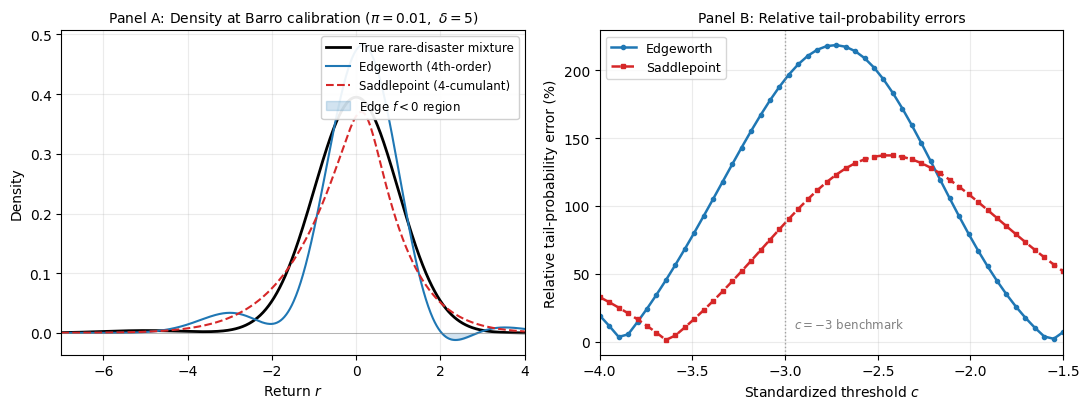

[Fig 1] Barro c=-3: true=0.011109, edge_err=193.34%, sad_err=87.38%
[Fig 2] lateral peak |gamma_1*|=0.6846 at gamma_2=2.5355
[Fig 2] grid: 648 cells, inside=81, outside=567 (87.5% outside)


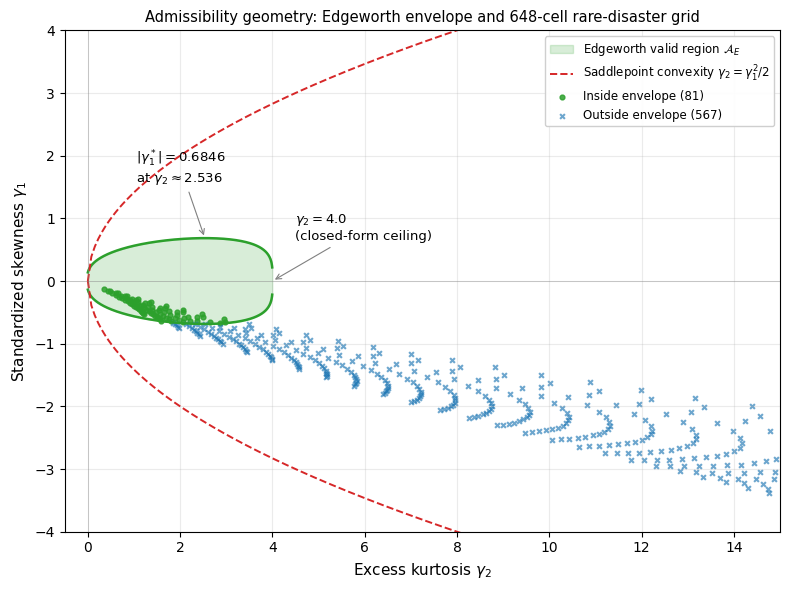

In [26]:
# ---------------------------------------------------------------------------
# Manuscript Figures 1 and 2 -- single-run reproduction from the model.
# Reuses the canonical RareDisasterModel / EdgeworthApproximation /
# SaddlepointApproximation classes and the closed-form envelope
# (find_critical_skewness / ENV_DF) defined earlier, so there is no duplicated
# model code. Output filenames match \includegraphics in the LaTeX source.
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

MS_FIGDIR = "."  # write next to the .tex (manuscript uses relative include paths)

# ---- Figure 1: Barro density + relative tail-probability error -------------
_m  = RareDisasterModel(pi=0.01, delta=5.0)
_eg = EdgeworthApproximation(_m)
_sd = SaddlepointApproximation(_m)

_x  = np.linspace(-7, 4, 1000)
_ft = np.array([_m.pdf(v)  for v in _x])
_fe = np.array([_eg.pdf(v) for v in _x])
_fs = np.array([_sd.pdf(v) for v in _x])

_cg = np.linspace(-4.0, -1.5, 50)
_ee = np.empty_like(_cg); _es = np.empty_like(_cg)
for _i, _c in enumerate(_cg):
    _pt = _m.tail_probability(_c)
    _ee[_i] = 100*abs(_eg.tail_probability(_c)-_pt)/_pt if _pt > 0 else np.nan
    _es[_i] = 100*abs(_sd.tail_probability(_c)-_pt)/_pt if _pt > 0 else np.nan

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot(_x, _ft, "k-", lw=2.0, label="True rare-disaster mixture")
ax1.plot(_x, _fe, color="#1f77b4", lw=1.5, label="Edgeworth (4th-order)")
ax1.plot(_x, _fs, color="#d62728", lw=1.5, ls="--", label="Saddlepoint (4-cumulant)")
_neg = _fe < 0
if _neg.any():
    ax1.fill_between(_x, _fe, 0, where=_neg, color="#1f77b4", alpha=0.2,
                     label=r"Edge $f<0$ region")
ax1.axhline(0, color="gray", lw=0.6, alpha=0.6)
ax1.set_xlabel(r"Return $r$"); ax1.set_ylabel("Density")
ax1.set_title(r"Panel A: Density at Barro calibration ($\pi=0.01,\ \delta=5$)", fontsize=10)
ax1.legend(loc="upper right", fontsize=8.5, framealpha=0.92); ax1.grid(alpha=0.25)
ax1.set_xlim(-7, 4)
ax2.plot(_cg, _ee, color="#1f77b4", lw=1.8, marker="o", markersize=3, label="Edgeworth")
ax2.plot(_cg, _es, color="#d62728", lw=1.8, marker="s", markersize=3, ls="--", label="Saddlepoint")
ax2.axvline(-3, color="gray", lw=1.0, ls=":", alpha=0.7)
ax2.text(-2.95, 8, r"$c=-3$ benchmark", fontsize=8.5, color="gray", va="bottom", ha="left")
ax2.set_xlabel(r"Standardized threshold $c$")
ax2.set_ylabel("Relative tail-probability error (%)")
ax2.set_title("Panel B: Relative tail-probability errors", fontsize=10)
ax2.legend(loc="upper left", fontsize=9); ax2.grid(alpha=0.25); ax2.set_xlim(-4, -1.5)
plt.tight_layout()
for _ext in ("pdf", "png"):
    fig.savefig(f"{MS_FIGDIR}/figure1_preview.{_ext}", dpi=200, bbox_inches="tight")
    fig.savefig(f"{OUTPUT_DIR}/figure1_preview.{_ext}", dpi=200, bbox_inches="tight")
plt.show()
_p3 = _m.tail_probability(-3)
print(f"[Fig 1] Barro c=-3: true={_p3:.6f}, "
      f"edge_err={100*abs(_eg.tail_probability(-3)-_p3)/_p3:.2f}%, "
      f"sad_err={100*abs(_sd.tail_probability(-3)-_p3)/_p3:.2f}%")

# ---- Figure 2: admissibility geometry + 648-cell grid ----------------------
# Lateral peak by continuous optimization (resolution-invariant), reproducing
# the text value |gamma_1*| ~ 0.6846 at gamma_2 ~ 2.533.
_peak = minimize_scalar(lambda g2: -float(find_critical_skewness(g2)),
                        bounds=(0.5, 3.5), method="bounded", options={"xatol": 1e-5})
PEAK_G2_FIG, PEAK_G1_FIG = float(_peak.x), float(-_peak.fun)
print(f"[Fig 2] lateral peak |gamma_1*|={PEAK_G1_FIG:.4f} at gamma_2={PEAK_G2_FIG:.4f}")

_g2g = np.linspace(0.0, 4.0, 801)
_g1s = np.array([find_critical_skewness(g) for g in _g2g])

_ag1, _ag2, _val = [], [], []
for _pi in PI_GRID:
    for _de in DEL_GRID:
        _k2 = 1.0 + _pi*(1-_pi)*_de**2
        _k3 = -_pi*(1-_pi)*(1-2*_pi)*_de**3
        _k4 = _pi*(1-_pi)*_de**4*(1-6*_pi*(1-_pi))
        _g1 = _k3/_k2**1.5; _g2 = _k4/_k2**2
        if _g2 > 4.0:
            _v = False
        else:
            _cs = find_critical_skewness(_g2)
            _v = (not np.isnan(_cs)) and abs(_g1) <= _cs
        _ag1.append(_g1); _ag2.append(_g2); _val.append(_v)
_ag1 = np.array(_ag1); _ag2 = np.array(_ag2); _val = np.array(_val)
_nin = int(_val.sum())
print(f"[Fig 2] grid: {len(_ag1)} cells, inside={_nin}, outside={len(_ag1)-_nin} "
      f"({100*(1-_val.mean()):.1f}% outside)")

fig, ax = plt.subplots(figsize=(8, 6))
_mask = _g1s > 0
ax.fill_between(_g2g[_mask], -_g1s[_mask], _g1s[_mask], color="#2ca02c", alpha=0.18,
                label=r"Edgeworth valid region $\mathcal{A}_E$")
ax.plot(_g2g, _g1s, color="#2ca02c", lw=1.8); ax.plot(_g2g, -_g1s, color="#2ca02c", lw=1.8)
_ge = np.linspace(0, 15, 200); _spc = np.sqrt(2*_ge)
ax.plot(_ge,  _spc, color="#d62728", lw=1.4, ls="--",
        label=r"Saddlepoint convexity $\gamma_2=\gamma_1^2/2$")
ax.plot(_ge, -_spc, color="#d62728", lw=1.4, ls="--")
ax.scatter(_ag2[_val],  _ag1[_val],  s=12, c="#2ca02c", alpha=0.85,
           label=f"Inside envelope ({_nin})")
ax.scatter(_ag2[~_val], _ag1[~_val], s=12, c="#1f77b4", alpha=0.65, marker="x",
           label=f"Outside envelope ({len(_ag1)-_nin})")
ax.annotate(rf"$|\gamma_1^*|={PEAK_G1_FIG:.4f}$" "\n" rf"at $\gamma_2\approx{PEAK_G2_FIG:.3f}$",
            xy=(PEAK_G2_FIG, PEAK_G1_FIG),
            xytext=(PEAK_G2_FIG-1.5, PEAK_G1_FIG+0.9), fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))
ax.annotate(r"$\gamma_2=4.0$" "\n(closed-form ceiling)", xy=(4.0, 0),
            xytext=(4.5, 0.65), fontsize=9.5,
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))
ax.axhline(0, color="gray", lw=0.5, alpha=0.5); ax.axvline(0, color="gray", lw=0.5, alpha=0.5)
ax.set_xlabel(r"Excess kurtosis $\gamma_2$", fontsize=11)
ax.set_ylabel(r"Standardized skewness $\gamma_1$", fontsize=11)
ax.set_title("Admissibility geometry: Edgeworth envelope and 648-cell rare-disaster grid",
             fontsize=10.5)
ax.legend(loc="upper right", fontsize=8.5, framealpha=0.93); ax.grid(alpha=0.25)
ax.set_xlim(-0.5, 15); ax.set_ylim(-4, 4)
plt.tight_layout()
for _ext in ("pdf", "png"):
    fig.savefig(f"{MS_FIGDIR}/figure2_preview.{_ext}", dpi=200, bbox_inches="tight")
    fig.savefig(f"{OUTPUT_DIR}/figure2_preview.{_ext}", dpi=200, bbox_inches="tight")
plt.show()


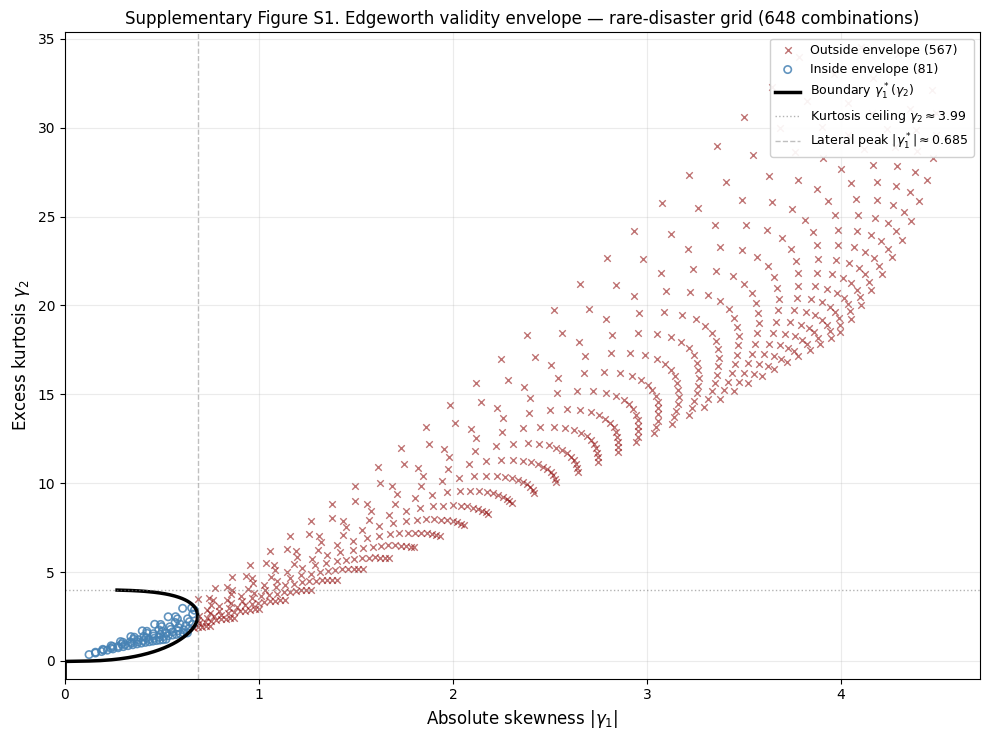

In [27]:
import matplotlib.pyplot as plt

# Figure 1
valid   = DF[~DF["neg_density"]]
invalid = DF[DF["neg_density"]]

fig, ax = plt.subplots(figsize=(10, 7.5))
ax.scatter(invalid["abs_gamma1"], invalid["gamma2"], s=22, c="darkred",
           alpha=0.55, marker="x", linewidths=1.0,
           label=f"Outside envelope ({len(invalid)})")
ax.scatter(valid["abs_gamma1"], valid["gamma2"], s=28, facecolors="none",
           edgecolors="steelblue", alpha=0.85, linewidths=1.2,
           label=f"Inside envelope ({len(valid)})")
th = ENV_DF.dropna(subset=["gamma_1_star"])
ax.plot( th["gamma_1_star"], th["gamma_2"], "k-", lw=2.5,
        label=r"Boundary $\gamma_1^*(\gamma_2)$")
ax.plot(-th["gamma_1_star"], th["gamma_2"], "k-", lw=2.5)
ax.axhline(G2_CEILING, color="gray", ls=":", lw=1.0, alpha=0.6,
           label=f"Kurtosis ceiling $\\gamma_2 \\approx {G2_CEILING:.2f}$")
ax.axvline(PEAK_G1, color="gray", ls="--", lw=1.0, alpha=0.5,
           label=f"Lateral peak $|\\gamma_1^*| \\approx {PEAK_G1:.3f}$")
ax.set_xlabel(r"Absolute skewness $|\gamma_1|$", fontsize=12)
ax.set_ylabel(r"Excess kurtosis $\gamma_2$", fontsize=12)
ax.set_title(f"Supplementary Figure S1. Edgeworth validity envelope — rare-disaster grid ({len(DF)} combinations)",
             fontsize=12)
ax.set_xlim(0, max(DF["abs_gamma1"].max() * 1.05, PEAK_G1 * 1.5))
ax.set_ylim(min(DF["gamma2"].min() - 0.5, -1), DF["gamma2"].max() + 0.8)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", fontsize=9, framealpha=0.92)
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/supplementary_figureS1_validity_envelope.png", dpi=200, bbox_inches="tight")
fig.savefig(f"{OUTPUT_DIR}/supplementary_figureS1_validity_envelope.pdf", format="pdf", bbox_inches="tight")
plt.show()

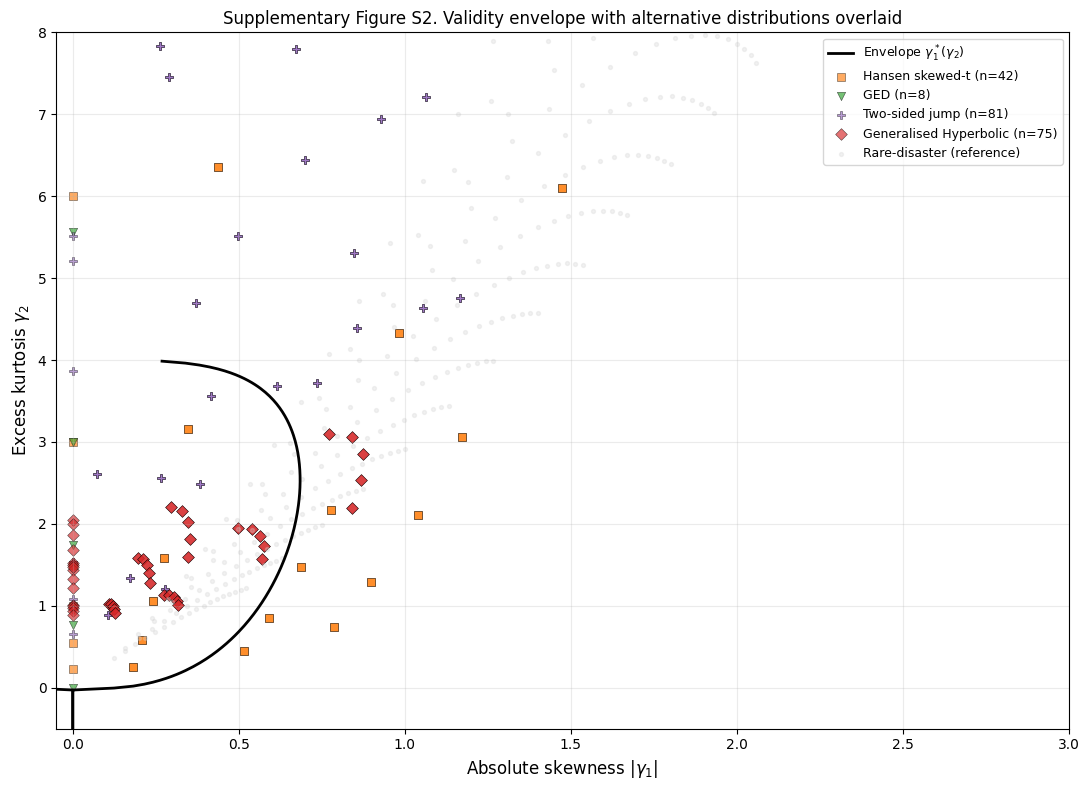

In [28]:
# Figure 2 — All four distributions overlaid on the envelope
fig, ax = plt.subplots(figsize=(11, 8))
th = ENV_DF.dropna(subset=["gamma_1_star"])
ax.plot( th["gamma_1_star"], th["gamma_2"], "k-", lw=2.0,
        label=r"Envelope $\gamma_1^*(\gamma_2)$")
ax.plot(-th["gamma_1_star"], th["gamma_2"], "k-", lw=2.0)

styles = {
    "Hansen skewed-t":         {"data": DF_HANSEN, "marker": "s", "color": "tab:orange"},
    "GED":                     {"data": DF_GED,    "marker": "v", "color": "tab:green"},
    "Two-sided jump":          {"data": DF_JUMP,   "marker": "P", "color": "tab:purple"},
    "Generalised Hyperbolic":  {"data": DF_GH,     "marker": "D", "color": "tab:red"},
}
for name, sty in styles.items():
    d = sty["data"]
    ax.scatter(d["abs_gamma1"], d["gamma2"], s=36, marker=sty["marker"],
               color=sty["color"], alpha=0.65, edgecolor="black", linewidth=0.4,
               label=f"{name} (n={len(d)})")

# Faint rare-disaster grid for visual reference (truncated to envelope range)
rd_lim = DF[DF["gamma2"] < 8]
ax.scatter(rd_lim["abs_gamma1"], rd_lim["gamma2"], s=8, c="lightgray", alpha=0.3,
           label="Rare-disaster (reference)")

ax.set_xlabel(r"Absolute skewness $|\gamma_1|$", fontsize=12)
ax.set_ylabel(r"Excess kurtosis $\gamma_2$", fontsize=12)
ax.set_title("Supplementary Figure S2. Validity envelope with alternative distributions overlaid", fontsize=12)
ax.set_xlim(-0.05, 3.0)
ax.set_ylim(-0.5, 8.0)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/supplementary_figureS2_distributions_overlay.png", dpi=200, bbox_inches="tight")
fig.savefig(f"{OUTPUT_DIR}/supplementary_figureS2_distributions_overlay.pdf", format="pdf", bbox_inches="tight")
plt.show()

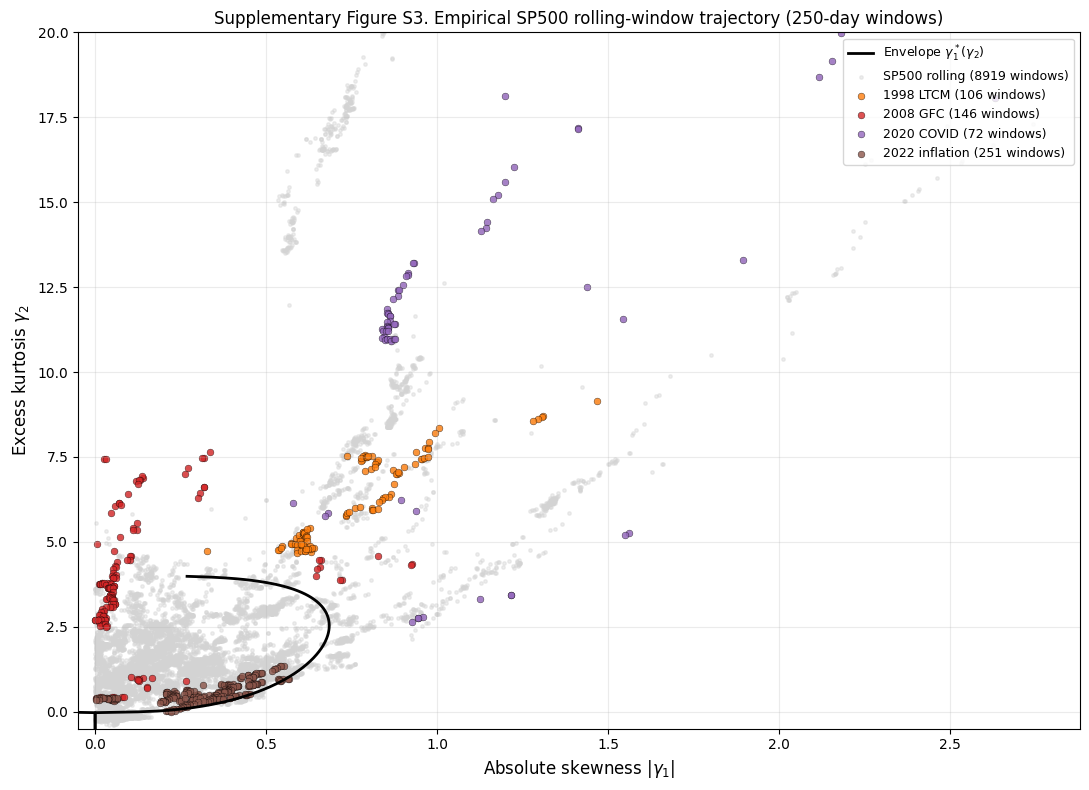

In [29]:
# Figure 3 — Empirical rolling-window trajectory through stress periods
fig, ax = plt.subplots(figsize=(11, 8))
th = ENV_DF.dropna(subset=["gamma_1_star"])
ax.plot( th["gamma_1_star"], th["gamma_2"], "k-", lw=2.0,
        label=r"Envelope $\gamma_1^*(\gamma_2)$")
ax.plot(-th["gamma_1_star"], th["gamma_2"], "k-", lw=2.0)

# Shade stress periods on SP500
stress = [
    ("1998 LTCM",      "1998-08-01", "1998-12-31", "tab:orange"),
    ("2008 GFC",       "2008-09-01", "2009-03-31", "tab:red"),
    ("2020 COVID",     "2020-02-15", "2020-05-31", "tab:purple"),
    ("2022 inflation", "2022-01-01", "2022-12-31", "tab:brown"),
]
sp = roll[roll["ticker"] == "SP500"].sort_values("date")
ax.scatter(sp["g1"].abs(), sp["g2"], s=6, c="lightgray", alpha=0.4,
           label=f"SP500 rolling ({len(sp)} windows)")
for label, lo, hi, col in stress:
    mask = (sp["date"] >= lo) & (sp["date"] <= hi)
    sub = sp[mask]
    if len(sub) > 0:
        ax.scatter(sub["g1"].abs(), sub["g2"], s=24, c=col, alpha=0.8,
                   edgecolor="black", linewidth=0.3,
                   label=f"{label} ({len(sub)} windows)")

ax.set_xlabel(r"Absolute skewness $|\gamma_1|$", fontsize=12)
ax.set_ylabel(r"Excess kurtosis $\gamma_2$", fontsize=12)
ax.set_title(f"Supplementary Figure S3. Empirical SP500 rolling-window trajectory ({ROLLING_WINDOW}-day windows)",
             fontsize=12)
ax.set_xlim(-0.05, max(2.0, sp["g1"].abs().max() * 1.05))
ax.set_ylim(-0.5, min(20, sp["g2"].max() * 1.1))
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/supplementary_figureS3_empirical_trajectory.png", dpi=200, bbox_inches="tight")
fig.savefig(f"{OUTPUT_DIR}/supplementary_figureS3_empirical_trajectory.pdf", format="pdf", bbox_inches="tight")
plt.show()

## 17. Monte Carlo validation

In [30]:
if MC_REPS == 0:
    print("[FAST_MODE] Monte Carlo skipped.")
    MC_RESULTS = {}
else:
    print(f"\nMonte Carlo: {MC_REPS} replications x {MC_SAMPLES:,} samples")
    print("Calibration: pi = 0.01, delta = 5")
    m_b  = RareDisasterModel(pi=0.01, delta=5.0)
    eg_b = EdgeworthApproximation(m_b)
    sd_b = SaddlepointApproximation(m_b)
    c = -3.0
    p_true = m_b.tail_probability(c)
    p_edge = eg_b.tail_probability(c)
    p_sad  = sd_b.tail_probability(c)
    np.random.seed(SEED)
    mc = [np.mean(m_b.simulate(MC_SAMPLES) < c) for _ in range(MC_REPS)]
    mc_mean, mc_std = np.mean(mc), np.std(mc, ddof=1)
    err_edge = 100 * abs(p_edge - mc_mean) / mc_mean
    err_sad  = 100 * abs(p_sad  - mc_mean) / mc_mean
    print(f"  True (analytical):   {p_true:.6f}")
    print(f"  MC mean +/- std:     {mc_mean:.6f} +/- {mc_std:.6f}")
    print(f"  Edgeworth:           {p_edge:.6f}  err vs MC: {err_edge:.2f}%")
    print(f"  Saddlepoint:         {p_sad:.6f}  err vs MC: {err_sad:.2f}%")
    MC_RESULTS = {"p_true": p_true, "mc_mean": mc_mean, "mc_std": mc_std,
                  "p_edge": p_edge, "p_sad": p_sad,
                  "err_edge_pct": err_edge, "err_sad_pct": err_sad}
    pd.DataFrame([MC_RESULTS]).to_csv(f"{OUTPUT_DIR}/table9_monte_carlo_validation.csv", index=False)


Monte Carlo: 100 replications x 100,000 samples
Calibration: pi = 0.01, delta = 5
  True (analytical):   0.011109
  MC mean +/- std:     0.011067 +/- 0.000309
  Edgeworth:           0.032586  err vs MC: 194.44%
  Saddlepoint:         0.020816  err vs MC: 88.08%


## 18. Numerical summary

In [31]:
m_b = RareDisasterModel(pi=0.01, delta=5.0)
eg_b = EdgeworthApproximation(m_b); sd_b = SaddlepointApproximation(m_b)
c = THRESHOLD_FOCUS
p_true_b = m_b.tail_probability(c)
err_edge_barro = 100 * abs(eg_b.tail_probability(c) - p_true_b) / p_true_b
err_sad_barro  = 100 * abs(sd_b.tail_probability(c) - p_true_b) / p_true_b

valid_mask = ~DF["neg_density"]; invalid_mask = DF["neg_density"]
min_g1_invalid = DF.loc[invalid_mask, "abs_gamma1"].min()
max_g1_valid   = DF.loc[valid_mask,   "abs_gamma1"].max()
invalid_share  = 100 * invalid_mask.mean()
dm_overall = dm_stat(DF["loss_diff"])
dm_by_regime = {r: dm_stat(DF[DF["regime"] == r]["loss_diff"])
                for r in ["Mild", "Moderate", "Severe", "Extreme"]}

DF["g1_star_theoretical"] = DF["gamma2"].apply(find_critical_skewness)
# When g1_star is NaN, the validity envelope is empty at this kurtosis, so
# every point at that kurtosis is outside the envelope. predicted_inside is
# True only when g1_star is finite AND |gamma_1| does not exceed it.
DF["predicted_inside"] = (
    DF["g1_star_theoretical"].notna()
    & (DF["abs_gamma1"] <= DF["g1_star_theoretical"])
)
DF["empirical_inside"] = ~DF["neg_density"]
n_consistent = int((DF["predicted_inside"] == DF["empirical_inside"]).sum())
DF.to_csv(f"{OUTPUT_DIR}/full_grid_results.csv", index=False)

lines = []
lines.append("=" * 78)
lines.append("NUMERICAL SUMMARY")
lines.append(f"Date: {datetime.now():%Y-%m-%d %H:%M}   Seed: {SEED}   "
             f"Mode: {'FAST' if FAST_MODE else 'FULL'}")
lines.append("=" * 78)
lines.append("")
lines.append("Calibration (Barro 2006: pi = 0.01, delta = 5, c = -3)")
lines.append(f"  Edgeworth relative error:     {err_edge_barro:>7.3f}%")
lines.append(f"  Saddlepoint relative error:   {err_sad_barro:>7.3f}%")
lines.append("")
lines.append("Validity envelope")
lines.append(f"  Kurtosis ceiling gamma_2:     {G2_CEILING:>7.4f}")
lines.append(f"  Lateral peak |gamma_1*|:      {PEAK_G1:>7.4f} at gamma_2 = {PEAK_G2:.4f}")
lines.append(f"  Fraction outside envelope:    {invalid_share:>7.3f}%")
lines.append(f"  Min |g1| invalid set:         {min_g1_invalid:>7.4f}")
lines.append(f"  Max |g1| valid set:           {max_g1_valid:>7.4f}")
lines.append(f"  Closed-form consistency:      {n_consistent}/{len(DF)}")
lines.append("")
lines.append("Diebold-Mariano statistics at c = -3 (positive = Saddlepoint better)")
for r in ["Mild", "Moderate", "Severe", "Extreme"]:
    lines.append(f"  {r:<12}                  {dm_by_regime[r]:>+8.3f}")
lines.append(f"  {'Overall':<12}                  {dm_overall:>+8.3f}")
lines.append("")
ESI_E = DF.loc[valid_mask,   'es_relerr_edge'].mean()
ESO_E = DF.loc[invalid_mask, 'es_relerr_edge'].mean()
ES_E_ALL = DF['es_relerr_edge'].mean()
ES_S_ALL = DF['es_relerr_sad'].mean()
lines.append("Expected Shortfall (alpha = 0.01)")
lines.append(f"  Edgeworth mean rel err full:  {ES_E_ALL:>7.3f}%")
lines.append(f"  Saddlepoint mean rel err full:{ES_S_ALL:>7.3f}%")
lines.append(f"  ES gap (Edge - Sad):          {ES_E_ALL-ES_S_ALL:>+7.3f} pp")
lines.append(f"  ES Edge inside envelope:      {ESI_E:>7.3f}%")
lines.append(f"  ES Edge outside envelope:     {ESO_E:>7.3f}%")
lines.append(f"  Amplification (outside/inside): {ESO_E/ESI_E:>7.3f}x")
lines.append("")
lines.append("Robustness across distributions (ES rel error %, mean)")
lines.append(f"  {'Family':<24} {'n':>5} {'Outside%':>9} {'EdgeIn':>8} {'EdgeOut':>9} {'SadIn':>8} {'SadOut':>9}")
for row in [robustness_summary("Rare-disaster", DF_rd_summary),
            robustness_summary("Hansen skewed-t", DF_HANSEN),
            robustness_summary("GED", DF_GED),
            robustness_summary("Two-sided jump", DF_JUMP),
            robustness_summary("Generalised Hyperbolic", DF_GH)]:
    lines.append(f"  {row['distribution']:<24} {row['n']:>5} "
                 f"{row['outside_envelope_pct']:>8.2f}% "
                 f"{row['edge_es_inside_pct']:>8.2f} "
                 f"{row['edge_es_outside_pct']:>9.2f} "
                 f"{row['sad_es_inside_pct']:>8.2f} "
                 f"{row['sad_es_outside_pct']:>9.2f}")
lines.append("")
lines.append("Empirical application")
sp_roll = roll[roll["ticker"] == "SP500"]
inside_pct_sp = 100 * (sp_roll["envelope"] == "inside").mean()
lines.append(f"  SP500 rolling windows ({ROLLING_WINDOW}d):  {len(sp_roll)}")
lines.append(f"  Inside envelope:                  {inside_pct_sp:>7.3f}%")
lines.append(f"  Outside envelope:                 {100-inside_pct_sp:>7.3f}%")
lines.append("")
if MC_RESULTS:
    lines.append("Monte Carlo (Barro calibration)")
    lines.append(f"  MC mean:                      {MC_RESULTS['mc_mean']:.6f} "
                 f"+/- {MC_RESULTS['mc_std']:.6f}")
    lines.append(f"  Edgeworth error vs MC:        {MC_RESULTS['err_edge_pct']:>7.3f}%")
    lines.append(f"  Saddlepoint error vs MC:      {MC_RESULTS['err_sad_pct']:>7.3f}%")
lines.append("=" * 78)

summary = "\n".join(lines)
print(summary)
with open(f"{OUTPUT_DIR}/numerical_summary.txt", "w") as f:
    f.write(summary)

NUMERICAL SUMMARY
Date: 2026-06-12 20:41   Seed: 456   Mode: FULL

Calibration (Barro 2006: pi = 0.01, delta = 5, c = -3)
  Edgeworth relative error:     193.336%
  Saddlepoint relative error:    87.377%

Validity envelope
  Kurtosis ceiling gamma_2:      3.9863
  Lateral peak |gamma_1*|:       0.6846 at gamma_2 = 2.5375
  Fraction outside envelope:     87.500%
  Min |g1| invalid set:          0.6631
  Max |g1| valid set:            0.6676
  Closed-form consistency:      648/648

Diebold-Mariano statistics at c = -3 (positive = Saddlepoint better)
  Mild                            +8.613
  Moderate                        +9.751
  Severe                          -1.934
  Extreme                        -17.706
  Overall                         -7.919

Expected Shortfall (alpha = 0.01)
  Edgeworth mean rel err full:   41.934%
  Saddlepoint mean rel err full: 12.823%
  ES gap (Edge - Sad):          +29.110 pp
  ES Edge inside envelope:        6.200%
  ES Edge outside envelope:      47.039%

In [32]:
print("Files in outputs/:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    sz = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"  {f:<42} {sz:>10,} bytes")

Files in outputs/:
  auxiliary_empirical_regime.csv                    399 bytes
  empirical_rolling.csv                       3,545,623 bytes
  figure1_preview.pdf                            30,091 bytes
  figure1_preview.png                           200,018 bytes
  figure2_preview.pdf                            47,531 bytes
  figure2_preview.png                           185,137 bytes
  full_grid_results.csv                         523,244 bytes
  numerical_summary.txt                           2,142 bytes
  robustness_ged.csv                              2,805 bytes
  robustness_gh.csv                              29,964 bytes
  robustness_hansen.csv                          16,336 bytes
  robustness_jump.csv                            31,525 bytes
  supplementary_figureS1_validity_envelope.pdf     32,868 bytes
  supplementary_figureS1_validity_envelope.png    196,702 bytes
  supplementary_figureS2_distributions_overlay.pdf     29,767 bytes
  supplementary_figureS2_distributions_ov